<a href="https://colab.research.google.com/github/WVF-1/The-Full-Monty/blob/main/FULPs_v1_Encephalon_Cora.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# FULPs Framework v1 — Encephalon / Skepsi, with FULP 8 Protogoal Formation### Validation run: Cora citation network, 50 seeds, vs. Random Forest and GCN+GAT baselinesThis notebook is the first full implementation of FULPs v1, built per the *FULPs Framework v1 — Architecture & Build Plan* (Architecture synthesis notes, William V. Fullerton / Conscientiâ Research Group). It follows that plan's conservative design philosophy: previously validated mechanisms (V2D's Skepsi/Encephalon math, the Computation-Budget scheduler's Thompson+MED mechanism) are carried forward as directly as possible; only FULP 8 (Mutation/Protogoal Formation) and the Perception-ARE / microcell mix are new implementation work.**What's carried forward unchanged:** FULP 1 (Void: IDF + VoidStabilizer + DSC), FULP 2 (Memory), FULP 3 (Context), FULP 6 (Peer Review, directed inbox with exclusion rule), FULP 7 (Contradiction Resolution) — all use the exact formulas from `FULPs_V2D_Synthesis`.**What's new in v1:**- **FULP 5, unified under one stochastic primitive** (`BetaEstimator` / `DirichletEstimator`, both already present in V2D but under-used): Perception-ARE (a Dirichlet prototype bank replacing the CA line's ad hoc pos/neg EMA buffers) and Trust-ARE (V2C/V2D's existing Thompson-sampled role weights) now share the same math.- **Microcells**, mixed per the plan: Pattern/Causality use a frequency-table mechanism generalizing the CA line's count table (Option 1); Trend/Prediction use small gradient-trained heads (Option 2). No sklearn RandomForest/DecisionTree/LogisticRegression anywhere inside Encephalon.- **FULP 8 (Protogoal Formation)** — previously `def mutate(self): pass` in every Full-Monty notebook through V3-NWU. Ported from the Computation-Budget scheduler's Thompson Sampling + MED + BEU mechanism (not the CA line's v7 arm-pool, which has a documented, unfixed convergence bug). Drives Progressive Spatial Attention candidate ordering, with a **non-circular reward**: a candidate Skepsi's belief updates on whether activating it *measurably* reduced symposium uncertainty, never on whether MED liked it.- **Online learning** (Sec. 8 of the plan): tables, gradient heads, prototypes, role vectors, reputation, and protogoal beliefs all keep updating for the life of the system; only the VoidStabilizer encoder stays frozen after Stage 0.**Two real bugs were found and fixed while building this notebook** (both documented inline where they occur): (1) `InnerDepthField`'s original per-sample dense Cholesky decomposition is O(d³) and hangs completely at Cora's dimensionality — replaced with an exact O(d) recursive AR(1) reformulation, same distribution. (2) The `dense=True` (uniform-depth) prediction path initially never computed a real fused prediction, silently defaulting to class 0 every time — fixed by factoring fusion into a shared helper used by both the adaptive and dense paths.**One empirical, evidence-based deviation from the plan's default:** Pattern/Causality's frequency-table mechanism (Option 1) was diagnosed on Cora to perform *at or below chance* (measured: Pattern 15%, Causality 8.7%, vs. 14.3% chance on 7 classes) — the coarse sign-quantization of an 860+-dimensional sparse bag-of-words subspace, with only ~140 training samples, doesn't carve out class-informative regions regardless of whether the projection is learned-via-reconstruction or fixed-random (both tested below). This is exactly the risk the plan flagged in Sec. 5.4 and reserved Option 2 as the fallback for — the diagnostic that justifies the override is included as its own cell so the decision isn't silent.

## Setup

In [1]:
!pip install -q torch torch_geometric scikit-learn scipy pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 896.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 16.7 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, accuracy_score
from scipy import stats
from torch_geometric.nn import GCNConv, GATConv
from torch_geometric.datasets import Planetoid
import time
import matplotlib.pyplot as plt

print('torch', torch.__version__)
import torch_geometric
print('torch_geometric', torch_geometric.__version__)

torch 2.11.0+cpu
torch_geometric 2.8.0.post1


## ConfigurationValues marked `(V2D)` are carried forward unchanged from `FULPs_V2D_Synthesis` — their stability across every notebook that uses them is itself the evidence they're correct. Values marked `(v1 new)` are new to this build.

In [3]:
class _Config:
    pass

C = _Config()

"""
Shared config for FULPs v1. Values marked '(V2D)' are carried forward
unchanged from FULPs_V2D_Synthesis -- the strongest signal available that
they're correct is that they're stable across every notebook that uses them.
New v1-only constants (FULP 8 protogoal engine, Perception-ARE) are marked
'(v1 new)'.
"""

# Grid (V2D)
__tmp = 9, 9
C.GRID_H = __tmp[0]
C.GRID_W = __tmp[1]
C.MAX_PSA_LEVELS = 2
C.SUBSPACE_FRAC = 0.6

# Acceptance thresholds (V2D)
C.CONF_ACCEPT = 0.60
C.CONT_ACCEPT = 0.25
C.CONF_EMERGENCY = 0.40
C.CONT_EMERGENCY = 0.45
C.MAX_CONTRADICTION_PASSES = 3
C.EARLY_STOP_CONTRADICTION = 0.10  # V2D's validated value (see Plan Sec.10 Q3)

# FULP 1 -- Void (V2D / Prototype line)
__tmp = 16, 0.3, 0.5
C.VOID_HIDDEN = __tmp[0]
C.EA_TARGET_STD = __tmp[1]
C.EA_WEIGHT = __tmp[2]
__tmp = 100, 128
C.VOID_EPOCHS = __tmp[0]
C.VOID_BATCH = __tmp[1]
C.DSC_CALIBRATION_PERCENTILE = 75

# FULP 2 -- Memory (V2D)
__tmp = 0.6, 0.95
C.WORKING_EMA = __tmp[0]
C.EPISODIC_EMA = __tmp[1]

# FULP 3 -- Context (V2D)
C.CONTEXT_ALPHA = 0.10

# FULP 4/5 -- Bayesian primitives (V2D)
C.BETA_ALPHA_INIT = 1.0
C.BETA_BETA_INIT = 1.0
C.DIRICHLET_INIT = 0.25
C.ROLE_INCREMENT = 1.0

# FULP 5 signal thresholds (V2D)
C.NOVELTY_ROLE_THRESH = 0.30
C.ANOMALY_ROLE_THRESH = 0.30
C.UNCERTAINTY_ROLE_THRESH = 0.35
C.CONSENSUS_CONT_THRESH = 0.20

C.ALL_ROLES = ['pattern', 'memory', 'trend', 'novelty', 'uncertainty',
             'causality', 'prediction', 'anomaly', 'consensus']

# Trust-ARE / Thompson Sampling over roles (V2C/V2D)
C.TS_ROLE_SEED = 42
C.COMPLEMENT_BIAS = 0.20

# Peer review (V2D)
C.BP_PEER_REVIEW_DAMPING = 0.30

# Perception-ARE (v1 new -- Architecture Plan Sec. 4.2)
C.PERCEPTION_CONF_GATE = 0.60
C.PERCEPTION_CONTRA_MARGIN = 0.15
C.PERCEPTION_PROTO_EMA = 0.90
C.CURIOSITY_BOOST = 1.5   # extra weight applied to microcell updates on contradiction

# FULP 8 -- Protogoal / Mutation engine (v1 new -- Architecture Plan Sec. 6)
# MED weighting -- ported verbatim from Computation-Budget scheduler.py
C.MED_W_ATTENTION = 0.35
C.MED_W_UNCERTAINTY = 0.35
C.MED_W_BEU = 0.20
C.MED_W_COST = 0.10
C.MED_LAMBDA = 0.10          # BEU = U - lambda*Cost
C.MED_LAPLACE_ALPHA = 0.01
C.THOMPSON_BLEND_GAMMA = 0.50  # combined = (1-gamma)*thompson_sample + gamma*MED_norm

# Microcells (v1 new -- Architecture Plan Sec. 5)
# TABLE_HIDDEN sets 2^TABLE_HIDDEN possible quantized states for the
# Option-1 frequency table. Must stay small relative to the training-set
# size or most held-out states are never observed and the table falls back
# to the uniform Laplace prior on every test sample (diagnosed empirically:
# hidden=8 -> 256 states vs Cora's ~140 training samples -> <1 sample/state
# on average -> Pattern/Causality contribute near-noise). hidden=4 -> 16
# states -> ~8.75 samples/state at Cora's standard 20-per-class convention.
C.TABLE_HIDDEN = 4
C.TABLE_ENCODER_EPOCHS = 60
__tmp = 1.5e-2, 25
C.TREND_LR = __tmp[0]
C.TREND_EPOCHS = __tmp[1]
__tmp = 3e-3, 60
C.PRED_LR = __tmp[0]
C.PRED_EPOCHS = __tmp[1]
C.SPEC_HIDDEN = 16
C.SPEC_WEIGHT_DECAY = 1e-3  # high-dim/low-N regularization for the gradient specialists

# Pattern/Causality mechanism: 'table' (Option 1, plan default) or
# 'specialist' (Option 2, the plan's own documented fallback -- Sec. 5.4).
# See microcells.py's MicrocellBank docstring for the empirical diagnostic
# that justifies overriding this to 'specialist' for the Cora run.
C.PATTERN_CAUSALITY_MODE = 'table'

# Baselines (V2D)
C.RF_N_ESTIMATORS = 100

# Experiment (V2D established N_RUNS=50 default; N_TEST_EVAL is v1-new --
# subsamples the held-out test pool per run to keep 50-run wall time
# tractable, see Architecture notes in the experiment cell)
C.GLOBAL_SEED = 42
C.TEST_SIZE = 0.25
C.N_RUNS = 50
C.N_TEST_EVAL = 150

C.STATE_INACTIVE = 'INACTIVE'
C.STATE_EVALUATING = 'EVALUATING'
C.STATE_PEER_REVIEW = 'PEER_REVIEW'


## FULP 1 — Void AwarenessCarried forward unchanged (config values) from the Prototype/Full-Monty line. **One fix**, documented in the class docstring below: `InnerDepthField.sample()` originally built a dense `d x d` correlation matrix and Cholesky-decomposed it *per sample* — fine at CA scale (d=9) but O(d³) and completely infeasible at Cora's d≈1433–2866 (confirmed: it hangs). Replaced with an exact O(d) recursive AR(1) reformulation — same stationary covariance, not an approximation.

In [4]:
"""
FULP 1 -- Void Awareness. Carried forward unchanged from The-Full-Monty /
FULPs-Framework-Prototype. Config values (VOID_HIDDEN=16, EA_TARGET_STD=0.3,
EA_WEIGHT=0.5) are stable across every repository read for the v1 plan --
that consistency is itself the evidence they're correct, so they are not
retuned here.
"""
import numpy as np
import torch
import torch.nn as nn
from scipy.linalg import cholesky

class InnerDepthField:
    """IDF -- Bayesian + Gaussian-copula structureless noise generator.

    Scaling note (v1): the original implementation built a dense d x d
    AR(1) correlation matrix and Cholesky-decomposed it PER SAMPLE. That's
    fine at CA scale (d=9) or Full-Monty scale (d<=11), but a per-sample
    dense Cholesky is O(d^3) -- at Cora's d=1433 (or 2866 with graph
    augmentation) that's computationally infeasible (confirmed: it hangs).
    The fix below is an EXACT reformulation, not an approximation: for an
    AR(1) correlation matrix (rho^|i-j|), the recursive formula
        x[0]     = mu + sig*e[0]
        x[i]     = mu + rho*(x[i-1]-mu) + sig*sqrt(1-rho^2)*e[i]
    produces a process with the identical stationary covariance
    Cov(x_i,x_j) = sig^2 * rho^|i-j| -- this is the textbook AR(1)/
    Ornstein-Uhlenbeck discrete-time construction, and it's what a Cholesky
    of this exact matrix structure computes internally anyway. Cost drops
    from O(d^3) per sample to O(d) per sample, vectorized across the batch."""

    def __init__(self, dim):
        self.dim = dim

    def sample(self, n, rng):
        mu = rng.normal(0, 0.02, size=n).astype(np.float32)
        sig = rng.uniform(0.05, 0.30, size=n).astype(np.float32)
        rho = rng.uniform(-0.2, 0.2, size=n).astype(np.float32)
        e = rng.normal(0, 1, size=(n, self.dim)).astype(np.float32)
        sqrt_term = np.sqrt(np.clip(1 - rho ** 2, 1e-8, None)).astype(np.float32)

        X = np.zeros((n, self.dim), dtype=np.float32)
        X[:, 0] = mu + sig * e[:, 0]
        for i in range(1, self.dim):
            X[:, i] = mu + rho * (X[:, i - 1] - mu) + sig * sqrt_term * e[:, i]
        return X

class VoidStabilizer(nn.Module):
    """Autoencoder trained only on IDF noise. Frozen permanently after Stage 0.
    dsc() -> Deviant Signal Channel (reconstruction error = novelty signal)."""

    def __init__(self, dim, hidden=16, ea_target_std=0.3, ea_weight=0.5):
        super().__init__()
        self.ea_target_std = ea_target_std
        self.ea_weight = ea_weight
        self.encoder = nn.Sequential(nn.Linear(dim, hidden), nn.Tanh())
        self.decoder = nn.Linear(hidden, dim)

    def forward(self, x):
        z = self.encoder(x)
        return self.decoder(z), z

    def encode(self, x):
        return self.encoder(x)

    def dsc(self, x):
        x_hat, _ = self.forward(x)
        return torch.mean((x - x_hat) ** 2, dim=1)

    def training_loss(self, x):
        x_hat, z = self.forward(x)
        recon = nn.functional.mse_loss(x_hat, x)
        ea = (z.std() - self.ea_target_std) ** 2
        return recon + self.ea_weight * ea, recon.item(), ea.item()

def train_void_stabilizer(dim, seed, n_epochs=100, batch_size=128,
                           hidden=16, ea_target_std=0.3, ea_weight=0.5, lr=1e-3):
    rng = np.random.default_rng(seed)
    idf = InnerDepthField(dim)
    model = VoidStabilizer(dim, hidden, ea_target_std, ea_weight)
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    for _ in range(n_epochs):
        x = torch.FloatTensor(idf.sample(batch_size, rng))
        loss, _, _ = model.training_loss(x)
        opt.zero_grad()
        loss.backward()
        opt.step()
    model.eval()
    for p in model.parameters():
        p.requires_grad = False
    return model, idf

def calibrate_dsc_threshold(void_model, idf, rng, X_scaled, percentile=75):
    """v1 uses the 75th-percentile convention (mature choice; see Architecture
    Plan Sec. 3) -- 'what counts as unusually novel against what's been seen',
    not FULP8-v0's original 25th-percentile 'what does void look like' framing."""
    with torch.no_grad():
        err = void_model.dsc(torch.FloatTensor(X_scaled.astype(np.float32))).numpy()
    return float(np.percentile(err, percentile))

## Shared stochastic primitive (FULP 4 / FULP 5 / FULP 8)`BetaEstimator` and `DirichletEstimator` are carried forward from `FULPs_V2D_Synthesis` Cell 5 (generalized so `DirichletEstimator` takes an arbitrary category list rather than a hardcoded role list). This is the one primitive reused at three scales in v1: Reputation (FULP 4), Trust-ARE and Perception-ARE (FULP 5), and the Protogoal engine (FULP 8).

In [5]:
"""
Shared stochastic belief primitive for FULPs v1 (FULP 4 / FULP 5 / FULP 8).

BetaEstimator and DirichletEstimator are carried forward verbatim in spirit
from FULPs_V2D_Synthesis (Cell 5), generalized only so DirichletEstimator
takes an arbitrary `categories` list instead of a hardcoded ALL_ROLES.
This is the one primitive reused at three scales in FULPs v1:
  - Reputation                (FULP 4)  -> BetaEstimator
  - Trust-ARE (role weights)  (FULP 5)  -> DirichletEstimator(categories=microcell roles)
  - Perception-ARE (prototypes)(FULP 5) -> DirichletEstimator(categories=prototype ids)
  - Protogoal / Mutation      (FULP 8)  -> BetaEstimator per candidate arm
"""
import numpy as np

class BetaEstimator:
    """Beta(alpha, beta) posterior over a binary outcome (success/failure)."""

    def __init__(self, alpha=1.0, beta=1.0):
        self.alpha = float(alpha)
        self.beta = float(beta)
        self._alpha0 = float(alpha)
        self._beta0 = float(beta)

    @property
    def mean(self):
        return self.alpha / (self.alpha + self.beta)

    @property
    def variance(self):
        a, b = self.alpha, self.beta
        return a * b / ((a + b) ** 2 * (a + b + 1))

    @property
    def concentration(self):
        return self.alpha + self.beta - self._alpha0 - self._beta0

    def sample(self, rng):
        return float(rng.beta(self.alpha, self.beta))

    def update(self, success, weight=1.0):
        if success:
            self.alpha += weight
        else:
            self.beta += weight

    def decay(self, factor):
        """Optional multiplicative decay toward the original prior (off by default)."""
        self.alpha = factor * self.alpha + (1 - factor) * self._alpha0
        self.beta = factor * self.beta + (1 - factor) * self._beta0

    def __repr__(self):
        return f"Beta(a={self.alpha:.2f},b={self.beta:.2f}) mean={self.mean:.3f}"

class DirichletEstimator:
    """
    Dirichlet posterior over an arbitrary category set.

    .means  -> deterministic posterior mean (pure exploitation; V2A/V2B style)
    .sample -> Thompson Sampling draw (exploration + exploitation; V2C/V2D style)
    Both read the SAME alpha vector -- callers choose which one to use.
    """

    def __init__(self, categories, alpha_init=0.25):
        self.categories = list(categories)
        self.alpha_init = float(alpha_init)
        self.alpha = {c: float(alpha_init) for c in self.categories}

    @property
    def means(self):
        total = sum(self.alpha.values())
        return {c: self.alpha[c] / total for c in self.categories}

    def sample(self, rng):
        vec = np.array([self.alpha[c] for c in self.categories])
        drawn = rng.dirichlet(vec)
        return {c: float(drawn[i]) for i, c in enumerate(self.categories)}

    @property
    def concentration(self):
        return sum(self.alpha.values()) - len(self.categories) * self.alpha_init

    @property
    def dominant(self):
        return max(self.alpha, key=self.alpha.get)

    @property
    def entropy(self):
        """Normalized Shannon entropy of the posterior MEAN distribution, in [0, 1]."""
        p = np.array(list(self.means.values()))
        p = np.clip(p, 1e-10, 1.0)
        if len(p) <= 1:
            return 0.0
        return float(-np.sum(p * np.log(p)) / np.log(len(p)))

    def margin(self):
        """Top-1 mean minus top-2 mean -- generalizes the CA line's pos_sim - neg_sim
        from exactly 2 classes to N. Used as the Perception-ARE contradiction signal."""
        m = sorted(self.means.values(), reverse=True)
        if len(m) < 2:
            return 1.0
        return float(m[0] - m[1])

    def add_category(self, name, alpha_init=None):
        """Grow the arm pool -- used by Perception-ARE / FULP 8 to spawn new candidates."""
        a0 = self.alpha_init if alpha_init is None else float(alpha_init)
        if name not in self.alpha:
            self.categories.append(name)
            self.alpha[name] = a0

    def update(self, category, increment=1.0):
        if category in self.alpha:
            self.alpha[category] += float(increment)

    def __repr__(self):
        return f"Dirichlet(dominant={self.dominant}, conc={self.concentration:.1f}, H={self.entropy:.3f})"

## FULP 2 (Memory) and FULP 3 (Context)Carried forward unchanged — plain dual-speed EMA trackers.

In [6]:
"""
FULP 2 -- Memory, and FULP 3 -- Context. Carried forward unchanged.
Both are plain EMA trackers; the interesting design work in v1 is in
FULP 5 / FULP 8, not here, so these stay exactly as validated.
"""

class MemoryTrace:
    """FULP 2 -- dual-speed EMA: a fast 'working' trace and a slow 'episodic'
    trace, blended 0.7/0.3. Mirrors the CA line's short/long-window symmetry
    that Trend (FULP 5 microcell) also echoes."""

    def __init__(self, working_ema=0.6, episodic_ema=0.95):
        self.working_ema = working_ema
        self.episodic_ema = episodic_ema
        self.working = None
        self.episodic = None

    def update(self, value):
        if self.working is None:
            self.working = float(value)
            self.episodic = float(value)
        else:
            self.working = self.working_ema * self.working + (1 - self.working_ema) * value
            self.episodic = self.episodic_ema * self.episodic + (1 - self.episodic_ema) * value

    @property
    def blended(self):
        if self.working is None:
            return 0.0
        return 0.7 * self.working + 0.3 * self.episodic

class ContextTrace:
    """FULP 3 -- single EMA over {confidence, contradiction, novelty} per Skepsi."""

    def __init__(self, alpha=0.10):
        self.alpha = alpha
        self.confidence = 0.5
        self.contradiction = 0.0
        self.novelty = 0.0

    def update(self, confidence=None, contradiction=None, novelty=None):
        a = self.alpha
        if confidence is not None:
            self.confidence = a * confidence + (1 - a) * self.confidence
        if contradiction is not None:
            self.contradiction = a * contradiction + (1 - a) * self.contradiction
        if novelty is not None:
            self.novelty = a * novelty + (1 - a) * self.novelty

## FULP 5, perception scale — Perception-AREReplaces the CA line's pos/neg EMA-buffer-and-cosine-margin mechanism with a `DirichletEstimator` seeded one prototype per class. `score()` is read-only (fast, per-sample, gates contradiction before any ground truth is available); `observe()` is the slow, ground-truth-grounded online update.

In [7]:
"""
FULP 5 -- Adaptive Recognition Engine (ARE), perception scale.

Replaces the CA line's ad hoc pos/neg EMA-buffer-and-cosine-margin mechanism
with a genuine instance of the shared DirichletEstimator (see estimators.py),
seeded with one prototype arm per class (Architecture Plan Sec. 4.2).

Two clocks, deliberately kept separate:
  - `score(z)`   : fast, per-sample, read-only. Cosine similarity of z to the
                   current EMA prototype centroids. This is what CA's
                   pos_sim/neg_sim margin generalizes into for N classes, and
                   it is what gates contradiction on THIS sample, before any
                   ground truth is available.
  - `observe(z, y)` : slow, online, ground-truth-grounded. Nudges the
                   prototype centroid for class y toward z, AND accumulates
                   real evidence in the shared Dirichlet (FULP 5 also feeding
                   FULP 8's downstream "how confidently has this Skepsi
                   recognized class c" signal).
"""
import numpy as np

def _cos(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na < 1e-8 or nb < 1e-8:
        return 0.0
    return float(np.dot(a, b) / (na * nb))

class PerceptionARE:
    def __init__(self, class_labels, latent_dim, proto_ema=0.9,
                 conf_gate=0.60, contra_margin=0.15):
        self.classes = list(class_labels)
        self.latent_dim = latent_dim
        self.proto_ema = proto_ema
        self.conf_gate = conf_gate
        self.contra_margin = contra_margin
        self.prototypes = {c: np.zeros(latent_dim, dtype=np.float32) for c in self.classes}
        self._seen = {c: False for c in self.classes}
        self.belief = DirichletEstimator(categories=self.classes, alpha_init=0.25)

    def score(self, z):
        """Read-only. Returns (margin, max_sim, best_class, contradiction)."""
        sims = {c: (_cos(z, self.prototypes[c]) + 1.0) / 2.0 if self._seen[c] else 0.0
                for c in self.classes}
        ordered = sorted(sims.values(), reverse=True)
        best_class = max(sims, key=sims.get)
        max_sim = ordered[0]
        margin = ordered[0] - ordered[1] if len(ordered) > 1 else 1.0
        contradiction = (margin < self.contra_margin) and (max_sim > self.conf_gate)
        return margin, max_sim, best_class, contradiction

    def observe(self, z, true_class):
        """Ground-truth-grounded online update (Architecture Plan Sec. 8: this
        stays online for the life of the system, unlike the encoder weights)."""
        if true_class not in self.prototypes:
            return
        if not self._seen[true_class]:
            self.prototypes[true_class] = z.copy()
            self._seen[true_class] = True
        else:
            e = self.proto_ema
            self.prototypes[true_class] = e * self.prototypes[true_class] + (1 - e) * z
        self.belief.update(true_class, increment=1.0)

## FULP 5 microcells5 of 9 are sklearn-free already and carried forward **verbatim** from `FULPs_V2D_Synthesis`'s `MicrocellBank.evaluate` — including the exact contradiction/confidence formulas: Memory, Novelty, Anomaly, Uncertainty, Consensus. The 4 sklearn microcells are replaced per the plan's mixed design:- **Pattern, Causality** → Option 1: `FrequencyTableMicrocell` (encoder + quantize + Laplace-smoothed count table, generalizing the CA line's validated mechanism)- **Trend, Prediction** → Option 2: `EDHSpecialistMicrocell` (small gradient-trained head, curiosity-weighted; Trend fast/high-LR, Prediction slow/low-LR — mirroring Memory's own working/episodic split)`MicrocellBank`'s `pattern_causality_mode` parameter is what the diagnostic cell below (in the Cora-specific section) uses to override Pattern/Causality to Option 2 for this dataset, with the measured evidence shown rather than silently substituted.

In [8]:
"""
FULP 5 microcells. 5 of 9 are sklearn-free already and carried forward
VERBATIM from FULPs_V2D_Synthesis (Cell 6, MicrocellBank.evaluate): Memory,
Novelty, Anomaly, Uncertainty, Consensus -- including the exact contradiction
and confidence formulas. The 4 sklearn microcells are replaced per the
Architecture Plan Sec. 5 (mixed Option 1 + Option 2, per Will's decision to
keep the mix rather than freeze it):

    Pattern    -> Option 1 (FrequencyTableMicrocell): encoder + quantize + count table
    Causality  -> Option 1 (FrequencyTableMicrocell): same mechanism, restricted subspace
    Trend      -> Option 2 (EDHSpecialistMicrocell): fast/high-LR gradient head
    Prediction -> Option 2 (EDHSpecialistMicrocell): slow/low-LR gradient head

Trend/Prediction's fast-vs-slow split deliberately mirrors Memory's own
working/episodic split (Architecture Plan Sec. 5.2).
"""
import numpy as np
import torch
import torch.nn as nn

# --------------------------------------------------------------------------
# Option 1: Frequency-table / prototype-bank microcell (Pattern, Causality)
# --------------------------------------------------------------------------
class FrequencyTableMicrocell:
    """Generalizes the CA line's Laplace-smoothed (state, class) count table
    from 9-bit binary CA neighborhoods to continuous features: a small
    encoder (same shape idea as VoidStabilizer, trained by reconstruction on
    THIS Skepsi's own real feature subspace, not void noise) compresses to a
    low-dim latent, which is quantized to a coarse discrete code (sign bits)
    for table lookup."""

    def __init__(self, in_dim, n_classes, hidden=8, seed=0, encoder_epochs=60, lr=1e-3):
        self.in_dim = in_dim
        self.n_classes = n_classes
        torch.manual_seed(seed)
        self.encoder = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh())
        self.decoder = nn.Linear(hidden, in_dim)
        self.encoder_epochs = encoder_epochs
        self.lr = lr
        self.counts = {}

    def _train_encoder(self, X):
        params = list(self.encoder.parameters()) + list(self.decoder.parameters())
        opt = torch.optim.Adam(params, lr=self.lr)
        Xt = torch.FloatTensor(X)
        for _ in range(self.encoder_epochs):
            z = self.encoder(Xt)
            xh = self.decoder(z)
            loss = nn.functional.mse_loss(xh, Xt)
            opt.zero_grad()
            loss.backward()
            opt.step()
        for p in params:
            p.requires_grad = False

    def _quantize(self, x_row):
        with torch.no_grad():
            z = self.encoder(torch.FloatTensor(x_row).unsqueeze(0)).numpy()[0]
        return tuple((z > 0).astype(int).tolist())

    def fit(self, X, y):
        self._train_encoder(X)
        for xi, yi in zip(X, y):
            self.update(xi, yi, curiosity_weight=1.0)
        return self

    def predict_proba(self, x_row):
        state = self._quantize(x_row)
        if state not in self.counts:
            return np.full(self.n_classes, 1.0 / self.n_classes)
        c = self.counts[state]
        return c / c.sum()

    def update(self, x_row, y_true, curiosity_weight=1.0):
        state = self._quantize(x_row)
        if state not in self.counts:
            self.counts[state] = np.ones(self.n_classes)  # Laplace prior
        self.counts[state][int(y_true)] += max(curiosity_weight, 1e-3)

# --------------------------------------------------------------------------
# Option 2: EDH-style gradient specialist microcell (Trend, Prediction)
# --------------------------------------------------------------------------
class EDHSpecialistMicrocell:
    """Small gradient-trained head, updated via a simplified generalization of
    the validated EDH Stage-3 loop: standard cross-entropy, with curiosity
    weighting (extra loss weight on samples Perception-ARE flags as
    contradicted) standing in for EDH's dir_loss contradiction-revision step
    -- simplified because that mechanism was built for VoidStabilizer's own
    latent space, not an arbitrary classification head."""

    def __init__(self, in_dim, n_classes, hidden=16, lr=5e-3, seed=0, weight_decay=1e-3):
        torch.manual_seed(seed)
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden), nn.Tanh(), nn.Linear(hidden, n_classes)
        )
        self.lr = lr
        self.opt = torch.optim.Adam(self.net.parameters(), lr=lr, weight_decay=weight_decay)
        self.n_classes = n_classes

    def fit(self, X, y, epochs=40):
        Xt = torch.FloatTensor(X)
        yt = torch.LongTensor(y.astype(int))
        for _ in range(epochs):
            logits = self.net(Xt)
            loss = nn.functional.cross_entropy(logits, yt)
            self.opt.zero_grad()
            loss.backward()
            self.opt.step()
        return self

    def predict_proba(self, x_row):
        with torch.no_grad():
            logits = self.net(torch.FloatTensor(x_row).unsqueeze(0))
            p = torch.softmax(logits, dim=1).numpy()[0]
        return p

    def update(self, x_row, y_true, curiosity_weight=1.0):
        xt = torch.FloatTensor(x_row).unsqueeze(0)
        yt = torch.LongTensor([int(y_true)])
        logits = self.net(xt)
        loss = nn.functional.cross_entropy(logits, yt) * curiosity_weight
        self.opt.zero_grad()
        loss.backward()
        self.opt.step()

# --------------------------------------------------------------------------
# MicrocellBank -- orchestrates all 9. Memory/Novelty/Anomaly/Uncertainty/
# Consensus/contradiction/confidence formulas below are VERBATIM from
# FULPs_V2D_Synthesis Cell 6 (MicrocellBank.evaluate).
# --------------------------------------------------------------------------
class MicrocellBank:
    def __init__(self, feature_idx, causal_idx, void_model, dsc_threshold, seed,
                 table_hidden=8, table_epochs=60,
                 trend_lr=1.5e-2, trend_epochs=25,
                 pred_lr=3e-3, pred_epochs=60,
                 spec_hidden=16, spec_weight_decay=1e-3,
                 pattern_causality_mode='table'):
        self.feature_idx = feature_idx
        self.causal_idx = causal_idx
        self.void_model = void_model
        self.dsc_threshold = dsc_threshold
        self.seed = seed

        self.table_hidden = table_hidden
        self.table_epochs = table_epochs
        self.trend_lr = trend_lr
        self.trend_epochs = trend_epochs
        self.pred_lr = pred_lr
        self.pred_epochs = pred_epochs
        self.spec_hidden = spec_hidden
        self.spec_weight_decay = spec_weight_decay
        # 'table' = Option 1 (Architecture Plan default). 'specialist' = the
        # Option 2 fallback the plan reserved for exactly this situation
        # (Sec. 5.4): empirically checked on Cora, and the frequency table
        # underperforms chance (diagnosed: 860-dim sparse BoW subspace,
        # ~140 training samples -> coarse sign-quantization doesn't carve
        # out class-informative regions, whether the projection is learned
        # via reconstruction or fixed-random -- see the notebook's
        # diagnostic cell for the measured numbers). Default stays 'table'
        # for datasets where the CA-line-style discretization is a good
        # fit; Cora's experiment config overrides this explicitly.
        self.pattern_causality_mode = pattern_causality_mode

        self.n_classes = None
        self.activated = False
        self.working_memory = None
        self.episodic_memory = None
        self._last_novelty = 0.0
        self._last_anomaly = 0.0

    def fit(self, X_train, y_train, n_classes):
        self.n_classes = n_classes
        Xs = X_train[:, self.feature_idx]
        Xc = X_train[:, self.causal_idx]

        # Option 1 or Option 2 for Pattern/Causality, per pattern_causality_mode
        if self.pattern_causality_mode == 'table':
            self.pattern_mc = FrequencyTableMicrocell(
                Xs.shape[1], n_classes, hidden=self.table_hidden, seed=self.seed,
                encoder_epochs=self.table_epochs).fit(Xs, y_train)
            self.causality_mc = FrequencyTableMicrocell(
                Xc.shape[1], n_classes, hidden=self.table_hidden, seed=self.seed + 1,
                encoder_epochs=self.table_epochs).fit(Xc, y_train)
        else:
            self.pattern_mc = EDHSpecialistMicrocell(
                Xs.shape[1], n_classes, hidden=self.spec_hidden, lr=self.trend_lr,
                seed=self.seed, weight_decay=self.spec_weight_decay).fit(Xs, y_train, epochs=self.trend_epochs)
            self.causality_mc = EDHSpecialistMicrocell(
                Xc.shape[1], n_classes, hidden=self.spec_hidden, lr=self.trend_lr,
                seed=self.seed + 1, weight_decay=self.spec_weight_decay).fit(Xc, y_train, epochs=self.trend_epochs)

        # Option 2 -- EDH-style gradient specialists (fast Trend / slow Prediction)
        self.trend_mc = EDHSpecialistMicrocell(
            Xs.shape[1], n_classes, hidden=self.spec_hidden, lr=self.trend_lr,
            seed=self.seed + 2, weight_decay=self.spec_weight_decay).fit(Xs, y_train, epochs=self.trend_epochs)
        self.prediction_mc = EDHSpecialistMicrocell(
            Xs.shape[1], n_classes, hidden=self.spec_hidden, lr=self.pred_lr,
            seed=self.seed + 3, weight_decay=self.spec_weight_decay).fit(Xs, y_train, epochs=self.pred_epochs)

        self._anomaly_mean = Xs.mean(axis=0)
        return self

    def reset_working_memory(self):
        self.working_memory = None

    def consolidate_memory(self, final_probs):
        if self.episodic_memory is None:
            self.episodic_memory = final_probs.copy()
        else:
            self.episodic_memory = 0.85 * self.episodic_memory + 0.15 * final_probs

    def online_update(self, x_full, y_true, curiosity_weight=1.0):
        """FULP 5 online updating (Architecture Plan Sec. 8): tables and
        gradient heads keep updating for the life of the system."""
        xs = x_full[self.feature_idx]
        xc = x_full[self.causal_idx]
        self.pattern_mc.update(xs, y_true, curiosity_weight)
        self.causality_mc.update(xc, y_true, curiosity_weight)
        self.trend_mc.update(xs, y_true, curiosity_weight)
        self.prediction_mc.update(xs, y_true, curiosity_weight)

    def evaluate(self, x_full, role_weights=None):
        self.activated = True
        n = self.n_classes
        xs = x_full[self.feature_idx]
        xc = x_full[self.causal_idx]

        pv = self.pattern_mc.predict_proba(xs)
        prv = self.prediction_mc.predict_proba(xs)
        tv = self.trend_mc.predict_proba(xs)
        cv = self.causality_mc.predict_proba(xc)

        # ---- novelty ----
        with torch.no_grad():
            dsc = float(self.void_model.dsc(torch.FloatTensor(x_full).unsqueeze(0)))
        nov = float(np.clip(dsc / (self.dsc_threshold + 1e-8) - 1.0, 0, 1))

        # ---- anomaly ----
        az = float(np.mean(np.abs(xs - self._anomaly_mean)))
        anom = float(np.clip((az - 1.0) / 2.0, 0, 1))

        self._last_novelty = nov
        self._last_anomaly = anom

        raw_avg = np.mean([pv, prv, tv, cv], axis=0)

        if self.working_memory is None:
            self.working_memory = raw_avg.copy()
        else:
            self.working_memory = 0.4 * self.working_memory + 0.6 * raw_avg

        if self.episodic_memory is not None:
            mv = 0.7 * self.working_memory + 0.3 * self.episodic_memory
        else:
            mv = self.working_memory.copy()

        vectors = [pv, prv, tv, cv, mv]
        if nov > 0.20:
            vectors.append(np.full(n, 1.0 / n))
        if anom > 0.20:
            vectors.append(np.full(n, 1.0 / n))

        all_v = np.stack(vectors)
        cons = np.mean(all_v, axis=0)

        p = np.clip(cons, 1e-9, 1.0)
        H = -np.sum(p * np.log(p)) / max(np.log(n), 1e-9)
        cc = int(np.argmax(cons))

        disagreement = np.mean([
            np.mean(np.abs(pv - prv)),
            np.mean(np.abs(pv - tv)),
            np.mean(np.abs(pv - cv)),
            np.mean(np.abs(pv - mv)),
        ])
        contradiction = float(np.clip(disagreement + 0.30 * anom + 0.30 * nov, 0, 1))

        confidence = float(np.clip(
            np.max(cons) * (1 - 0.4 * H) * (1 - 0.3 * nov) * (1 - 0.2 * anom), 0, 1))

        return {
            'probs': cons, 'prediction': cc, 'confidence': confidence,
            'contradiction': contradiction, 'novelty': nov, 'anomaly': anom,
            'uncertainty': H, 'memory_vec': mv, 'n_microcells_run': len(vectors),
            'microcell_predictions': {
                'pattern': int(np.argmax(pv)), 'prediction': int(np.argmax(prv)),
                'trend': int(np.argmax(tv)), 'causality': int(np.argmax(cv)),
                'memory': int(np.argmax(mv)),
            },
        }

## FULP 8 — Protogoal Formation / MutationThis was `def mutate(self): pass` in every Full-Monty notebook through V3-NWU. Ported from the Computation-Budget scheduler (Thompson Sampling + MED + BEU) rather than the CA line's v7 arm-pool, because the scheduler went through an explicit bug-fix cycle removing a **circular reward** (an earlier version rewarded a node's belief for having above-median MED at *selection* time — rewarding agreement with the selecting heuristic), while the CA arm-pool's own final write-up documents an *unfixed* convergence bug (unconditional mutation-eviction every switch interval).Drives Progressive Spatial Attention candidate ordering: "which not-yet-active Skepsi is worth activating next" becomes a genuine Beta-belief bandit decision. Complement-bias isn't discarded — it becomes the "Attention" ingredient inside MED, the same role a bolted-on GAT-style scorer plays in the original scheduler for architectures with no native attention.**Reward grounding (non-negotiable)**: a position's belief updates on whether activating it *measurably* reduced aggregate symposium uncertainty, never on whether MED/Thompson liked it.

In [9]:
"""
FULP 8 -- Protogoal Formation / Mutation. This is the layer that was
`def mutate(self): pass` in every Full-Monty notebook through V3-NWU
(Architecture Plan Sec. 1 & 6). Ported from Computation-Budget's
scheduler.py rather than the CA line's v7 arm-pool, because the scheduler
went through an explicit bug-fix cycle (removing a circular reward: an
earlier version rewarded a node's belief for having above-median MED at
SELECTION time, which just rewards agreement with the selecting heuristic)
and the CA arm-pool's own final write-up documents an unfixed convergence
bug (unconditional mutation-eviction every switch interval). See
Architecture Plan Sec. 6.1.

Concretely drives Progressive Spatial Attention (PSA) candidate ordering:
"which not-yet-active Skepsi is worth activating next" becomes a genuine
Beta-belief bandit decision (arms = grid positions) instead of a fixed
complement-bias heuristic. Complement-bias is not discarded -- it becomes
the "Attention" ingredient inside MED, exactly the role a bolted-on
GAT-style attention scorer plays in the original scheduler for architectures
(GCN/GIN) that have no native attention.

Reward grounding (non-negotiable, per the scheduler's own fix): a position's
Beta belief updates on whether activating it MEASURABLY reduced aggregate
symposium uncertainty (uncertainty_before - uncertainty_after > 0), never on
whether MED/Thompson liked the position. This is what makes it a genuine
protogoal-formation mechanism rather than a heuristic congratulating itself.

Microcell-arm evolution (K candidate variants per microcell) is a natural
extension of this same engine but is left as a hook, not built out in v1
-- see Architecture Plan Sec. 5.2 / 6.3 ("held in reserve").
"""
import numpy as np

class ProtogoalEngine:
    def __init__(self, seed):
        self.rng = np.random.default_rng(seed)
        self.beliefs = {}
        self.trials = {}

    def _belief(self, pos):
        if pos not in self.beliefs:
            self.beliefs[pos] = BetaEstimator(C.BETA_ALPHA_INIT, C.BETA_BETA_INIT)
            self.trials[pos] = 0
        return self.beliefs[pos]

    def attention(self, pos, complement_score, reputation):
        return float(0.5 * complement_score + 0.5 * reputation)

    def rank_candidates(self, candidates, attention_scores, current_uncertainty):
        """Returns `candidates` re-ordered by combined Thompson+MED score
        (highest priority first). `attention_scores`: dict pos -> [0,1]."""
        if not candidates:
            return candidates
        meds = {}
        for pos in candidates:
            a = attention_scores.get(pos, 0.5)
            u = current_uncertainty
            cost = self.trials.get(pos, 0)
            beu = u - C.MED_LAMBDA * cost
            meds[pos] = (C.MED_W_ATTENTION * a + C.MED_W_UNCERTAINTY * u
                         + C.MED_W_BEU * beu - C.MED_W_COST * cost)
        vals = np.array(list(meds.values()))
        vmin, vmax = float(vals.min()), float(vals.max())
        span = (vmax - vmin) if vmax > vmin else 1.0
        med_norm = {pos: (meds[pos] - vmin) / span for pos in candidates}
        med_norm = {pos: (v + C.MED_LAPLACE_ALPHA) / (1 + C.MED_LAPLACE_ALPHA)
                    for pos, v in med_norm.items()}

        combined = {}
        for pos in candidates:
            theta = self._belief(pos).sample(self.rng)
            g = C.THOMPSON_BLEND_GAMMA
            combined[pos] = (1 - g) * theta + g * med_norm[pos]

        return sorted(candidates, key=lambda p: -combined[p])

    def record_trial(self, positions):
        for pos in positions:
            self.trials[pos] = self.trials.get(pos, 0) + 1

    def record_outcome(self, positions, uncertainty_before, uncertainty_after):
        """The non-circular reward: measured benefit, not heuristic agreement."""
        success = (uncertainty_before - uncertainty_after) > 1e-9
        for pos in positions:
            self._belief(pos).update(success)

    def mutation_success_rate(self):
        """Adaptation metric (doc1's metric #9): fraction of recorded trials
        across all arms whose most recent belief update was a success, proxied
        here by the posterior mean weighted by trial count."""
        total_trials = sum(self.trials.values())
        if total_trials == 0:
            return float('nan')
        weighted = sum(self._belief(p).mean * self.trials[p] for p in self.trials)
        return weighted / total_trials

    def selection_consistency(self, history):
        """Adaptation/stability metric (doc1's metric #10): fraction of
        consecutive PSA expansions in `history` (a list of position-sets, one
        per sample) whose top-ranked candidate repeats. Simple, interpretable
        proxy for 'does the scheduler settle or thrash'."""
        if len(history) < 2:
            return float('nan')
        same = 0
        for a, b in zip(history[:-1], history[1:]):
            if a and b and a[0] == b[0]:
                same += 1
        return same / (len(history) - 1)

## Skepsi and EncephalonPeer review (FULP 6), contradiction resolution (FULP 7), and PSA structure below carry forward the same mathematics as `FULPs_V2D_Synthesis`. New relative to V2D: each Skepsi owns a `PerceptionARE` alongside its existing Trust-ARE `role_dirichlet`; `Encephalon` owns a `ProtogoalEngine` (FULP 8); `Skepsi.online_update()` / `Encephalon.partial_fit_single()` implement the online-learning boundary (tables/heads/prototypes/role-vectors/reputation/protogoal beliefs keep updating for the life of the system; only the VoidStabilizer encoder stays frozen).**Bug fix, found during review**: the `dense=True` (uniform-depth / no-scheduling) prediction path originally activated every Skepsi and resolved contradictions, but the code that fuses active Skepsis into a final prediction lived *only* inside the incremental PSA loop, which `dense=True` deliberately skips — so `dense` mode silently defaulted to `prediction=0` on every single call, regardless of what the 81 activated Skepsis actually believed. Fixed by factoring fusion into `_fuse_active()`, called from both paths. Verified below: dense predictions are non-degenerate and span the full label set once fixed.**Also new**: `_build_grid`'s `own_range` parameter. V2D's default always unions `causal_idx` into every Skepsi's feature subspace; for datasets with a genuine own/neighbor split (Cora, via the graph-feature augmentation below), `feature_idx` and `causal_idx` are sampled from disjoint pools instead, so Pattern (intrinsic node features) and Causality (neighbor-induced features) actually see different information.

In [10]:
"""
Skepsi and Encephalon. Peer review, contradiction resolution, PSA structure,
and all V2D formulas below are carried forward with the SAME mathematics as
FULPs_V2D_Synthesis (Architecture Plan Sec. 7: "carry forward unchanged").
Three things are new relative to V2D:

  1. Each Skepsi owns a PerceptionARE (FULP 5, perception scale) alongside
     its existing Trust-ARE role_dirichlet (FULP 5, trust scale) -- both
     built on the same DirichletEstimator primitive (Architecture Plan Sec 4).
  2. Encephalon owns a ProtogoalEngine (FULP 8) that ranks PSA candidates
     and is updated with a measured, non-circular reward (Sec. 6).
  3. Skepsi.online_update() / Encephalon.partial_fit_single() implement the
     Sec. 8 online-learning boundary: tables, gradient heads, prototypes,
     role vectors, reputation, and protogoal beliefs keep updating for the
     life of the system; only the VoidStabilizer encoder stays frozen.
"""
import numpy as np
from collections import Counter
from sklearn.preprocessing import StandardScaler

def log_combine_probs(probs_list, weights):
    """V2D verbatim -- reputation-weighted geometric mean (log-linear pool)."""
    w = np.array(weights, dtype=np.float64)
    w = w / (w.sum() + 1e-10)
    log_p = np.zeros_like(probs_list[0], dtype=np.float64)
    for p, wi in zip(probs_list, w):
        log_p += wi * np.log(np.clip(p, 1e-10, 1.0))
    log_p -= log_p.max()
    out = np.exp(log_p)
    return out / (out.sum() + 1e-10)

def _vn_shell(row, col, level, H, W):
    if level == 0:
        return [(row, col)]
    cells = []
    for dr in range(-level, level + 1):
        dc_abs = level - abs(dr)
        for dc in ([dc_abs, -dc_abs] if dc_abs != 0 else [0]):
            r, c = row + dr, col + dc
            if 0 <= r < H and 0 <= c < W:
                cells.append((r, c))
    return cells

def _vn_up_to(row, col, level, H, W):
    cells = set()
    for lv in range(level + 1):
        cells.update(_vn_shell(row, col, lv, H, W))
    return sorted(cells)

class Skepsi:
    def __init__(self, row, col, feature_idx, causal_idx, void_model, dsc_threshold, seed):
        self.row, self.col = row, col
        self.bank = MicrocellBank(feature_idx, causal_idx, void_model, dsc_threshold, seed,
                                   table_hidden=C.TABLE_HIDDEN, table_epochs=C.TABLE_ENCODER_EPOCHS,
                                   trend_lr=C.TREND_LR, trend_epochs=C.TREND_EPOCHS,
                                   pred_lr=C.PRED_LR, pred_epochs=C.PRED_EPOCHS,
                                   spec_hidden=C.SPEC_HIDDEN, spec_weight_decay=C.SPEC_WEIGHT_DECAY,
                                   pattern_causality_mode=C.PATTERN_CAUSALITY_MODE)
        self.void_model = void_model
        self.state = C.STATE_INACTIVE
        self.result = None
        self.initial_result = None

        self.rep_beta = BetaEstimator(C.BETA_ALPHA_INIT, C.BETA_BETA_INIT)
        self.role_dirichlet = DirichletEstimator(categories=C.ALL_ROLES, alpha_init=C.DIRICHLET_INIT)
        self.coop_beta = BetaEstimator(C.BETA_ALPHA_INIT, C.BETA_BETA_INIT)
        self.context = {'samples_seen': 0, 'avg_confidence': 0.0,
                         'avg_contradiction': 0.0, 'avg_novelty': 0.0}

        self.ts_rng = np.random.default_rng(seed + C.TS_ROLE_SEED)
        self.sampled_role_history = []
        self.sampled_weights_last = None

        self.local_evidence = None
        self.inbox = {}
        self.outbox = {}
        self.perception_are = None  # instantiated in fit() once n_classes known
        self._last_perception_contradiction = False

    def fit(self, X_train, y_train, n_classes):
        self.bank.fit(X_train, y_train, n_classes)
        classes = list(range(n_classes))
        self.perception_are = PerceptionARE(
            classes, latent_dim=C.VOID_HIDDEN, proto_ema=C.PERCEPTION_PROTO_EMA,
            conf_gate=C.PERCEPTION_CONF_GATE, contra_margin=C.PERCEPTION_CONTRA_MARGIN)
        import torch
        with torch.no_grad():
            Z = self.void_model.encode(torch.FloatTensor(X_train)).numpy()
        for zi, yi in zip(Z, y_train):
            self.perception_are.observe(zi, int(yi))
        return self

    @property
    def reputation(self):
        return self.rep_beta.mean

    @property
    def cooperation(self):
        return self.coop_beta.mean

    @property
    def role_vector(self):
        return self.role_dirichlet.means

    @property
    def dominant_role(self):
        return self.role_dirichlet.dominant

    @property
    def stubbornness(self):
        if self.result is not None:
            return float(np.clip(self.rep_beta.mean * self.result['confidence'], 0.05, 0.95))
        return float(np.clip(self.rep_beta.mean, 0.05, 0.95))

    @property
    def is_accepted(self):
        if self.result is None:
            return False
        return self.result['confidence'] >= C.CONF_ACCEPT and self.result['contradiction'] <= C.CONT_ACCEPT

    def reset(self):
        self.state = C.STATE_INACTIVE
        self.result = None
        self.initial_result = None
        self.bank.reset_working_memory()
        self.local_evidence = None
        self.inbox = {}
        self.outbox = {}

    def activate(self, x_scaled, void_z, state=C.STATE_EVALUATING):
        self.state = state
        sampled_weights = self.role_dirichlet.sample(self.ts_rng)
        self.sampled_weights_last = sampled_weights
        sampled_dom = max(sampled_weights, key=sampled_weights.get)
        self.sampled_role_history.append(sampled_dom)
        raw = self.bank.evaluate(x_scaled, role_weights=sampled_weights)
        self.initial_result = {k: raw[k].copy() if isinstance(raw[k], np.ndarray) else raw[k] for k in raw}
        self.result = raw
        self.local_evidence = raw['probs'].copy()

        # Perception-ARE (FULP 5, perception scale): read-only contradiction
        # signal for THIS sample, feeding curiosity weighting at update time.
        _, _, _, contra = self.perception_are.score(void_z)
        self._last_perception_contradiction = contra
        return self.result

    def compute_message_to(self, target_pos):
        if self.local_evidence is None:
            return None
        log_msg = self.rep_beta.mean * np.log(np.clip(self.local_evidence, 1e-10, 1.0))
        for sender_pos, msg_info in self.inbox.items():
            if sender_pos != target_pos:
                w = msg_info.get('reputation', 0.5)
                log_msg += w * np.log(np.clip(msg_info['probs'], 1e-10, 1.0))
        log_msg -= log_msg.max()
        new_msg = np.exp(log_msg)
        new_msg /= new_msg.sum() + 1e-10
        if target_pos in self.outbox:
            d = C.BP_PEER_REVIEW_DAMPING
            new_msg = (1 - d) * new_msg + d * self.outbox[target_pos]
            new_msg /= new_msg.sum() + 1e-10
        return new_msg

    def receive_directed_message(self, sender_pos, msg):
        if msg is not None:
            self.inbox[sender_pos] = {
                'probs': msg['probs'].copy() if isinstance(msg['probs'], np.ndarray) else msg['probs'],
                'reputation': msg.get('reputation', 0.5),
            }

    def apply_directed_messages(self):
        if self.local_evidence is None or self.result is None:
            return self.result
        log_b = self.rep_beta.mean * np.log(np.clip(self.local_evidence, 1e-10, 1.0))
        for msg_info in self.inbox.values():
            w = msg_info.get('reputation', 0.5)
            log_b += w * np.log(np.clip(msg_info['probs'], 1e-10, 1.0))
        log_b -= log_b.max()
        belief = np.exp(log_b)
        belief /= belief.sum() + 1e-10
        self.result['probs'] = belief
        self.result['prediction'] = int(np.argmax(belief))
        self.result['confidence'] = float(np.max(belief))
        return self.result

    def update_context(self, result):
        n = self.context['samples_seen']
        if n == 0:
            self.context.update(avg_confidence=result['confidence'],
                                 avg_contradiction=result['contradiction'],
                                 avg_novelty=result.get('novelty', 0.0))
        else:
            a = C.CONTEXT_ALPHA
            self.context['avg_confidence'] = (1 - a) * self.context['avg_confidence'] + a * result['confidence']
            self.context['avg_contradiction'] = (1 - a) * self.context['avg_contradiction'] + a * result['contradiction']
            self.context['avg_novelty'] = (1 - a) * self.context['avg_novelty'] + a * result.get('novelty', 0.0)
        self.context['samples_seen'] += 1

    def update_reputation(self, was_correct):
        self.rep_beta.update(was_correct)

    def update_role_vector(self, result, was_correct, agreed):
        if not was_correct:
            return
        sampled_role = self.sampled_role_history[-1]
        self.role_dirichlet.update(sampled_role, C.ROLE_INCREMENT)
        novelty = result.get('novelty', 0.0)
        anomaly = result.get('anomaly', 0.0)
        uncertainty = result.get('uncertainty', 1.0)
        contradiction = result.get('contradiction', 1.0)
        if novelty > C.NOVELTY_ROLE_THRESH:
            self.role_dirichlet.update('novelty', 0.5)
        if anomaly > C.ANOMALY_ROLE_THRESH:
            self.role_dirichlet.update('anomaly', 0.5)
        if uncertainty < C.UNCERTAINTY_ROLE_THRESH:
            self.role_dirichlet.update('uncertainty', 0.5)
        if contradiction < C.CONSENSUS_CONT_THRESH and agreed:
            self.role_dirichlet.update('consensus', 0.5)

    def update_cooperation(self, was_in_peer_review, prediction_correct):
        if was_in_peer_review:
            self.coop_beta.update(prediction_correct)

    def consolidate_memory(self):
        if self.result is not None:
            self.bank.consolidate_memory(self.result['probs'])

    def online_update(self, x_scaled, void_z, y_true):
        """Sec. 8 online-learning boundary: called once ground truth is known.
        Curiosity weight comes from the READ-ONLY Perception-ARE signal
        captured at activate()-time, then prototypes/Dirichlet are updated."""
        weight = C.CURIOSITY_BOOST if self._last_perception_contradiction else 1.0
        self.bank.online_update(x_scaled, y_true, curiosity_weight=weight)
        self.perception_are.observe(void_z, int(y_true))

    def __repr__(self):
        return (f'Skepsi({self.row},{self.col}) rep={self.reputation:.2f} '
                f'coop={self.cooperation:.2f} dominant={self.dominant_role} state={self.state}')

class Encephalon:
    def __init__(self, grid_h=None, grid_w=None, subspace_frac=None, void_seed=None, seed=None):
        self.grid_h = grid_h or C.GRID_H
        self.grid_w = grid_w or C.GRID_W
        self.center = (self.grid_h // 2, self.grid_w // 2)
        self.subspace_frac = subspace_frac if subspace_frac is not None else C.SUBSPACE_FRAC
        self.seed = seed if seed is not None else C.GLOBAL_SEED
        self.void_seed = void_seed if void_seed is not None else C.GLOBAL_SEED
        self.rng = np.random.default_rng(self.seed)
        self.scaler = StandardScaler()
        self.void_model = None
        self.idf = None
        self.dsc_threshold = None
        self.n_classes = None
        self.n_features = None
        self.grid = None
        self._plato = None
        self.protogoal = ProtogoalEngine(seed=self.seed + 777)
        self._psa_top_history = []  # for selection_consistency metric

    @property
    def plato(self):
        return self._plato

    def _build_grid(self, causal_idx, own_range=None):
        """own_range=None reproduces V2D's default behavior (sample from all
        features, union causal_idx in). When own_range is given (e.g. Cora's
        [0,1433) own-feature block), feature_idx is sampled ONLY from
        own_range and causal_idx is kept disjoint -- see graph_data.py's
        module docstring for why this matters for Pattern vs Causality."""
        if own_range is None:
            pool = list(range(self.n_features))
            force_union = True
        else:
            pool = list(own_range)
            force_union = False
        n_sub = max(1, int(len(pool) * self.subspace_frac))
        grid = []
        for r in range(self.grid_h):
            row = []
            for c in range(self.grid_w):
                chosen = set(self.rng.choice(pool, n_sub, replace=False).tolist())
                if force_union:
                    chosen |= set(causal_idx)
                sub = sorted(chosen)
                seed = int(self.rng.integers(0, 1_000_000))
                sk = Skepsi(r, c, sub, causal_idx, self.void_model, self.dsc_threshold, seed)
                row.append(sk)
            grid.append(row)
        cr, cc = self.center
        self._plato = grid[cr][cc]
        return grid

    def fit(self, X, y, n_classes, causal_idx=None, own_range=None, verbose=True):
        X_raw = X.astype(np.float32)
        self.n_features = X_raw.shape[1]
        self.n_classes = n_classes
        if causal_idx is None:
            causal_idx = [0, 1] if self.n_features >= 2 else [0]
        if verbose:
            print('  [Enc] Training VoidStabilizer (FULP 1)...')
        self.void_model, self.idf = train_void_stabilizer(
            self.n_features, seed=self.void_seed, n_epochs=C.VOID_EPOCHS,
            batch_size=C.VOID_BATCH, hidden=C.VOID_HIDDEN,
            ea_target_std=C.EA_TARGET_STD, ea_weight=C.EA_WEIGHT)
        rng_cal = np.random.default_rng(self.void_seed)
        X_scaled = self.scaler.fit_transform(X_raw).astype(np.float32)
        self.dsc_threshold = calibrate_dsc_threshold(
            self.void_model, self.idf, rng_cal, X_scaled, percentile=C.DSC_CALIBRATION_PERCENTILE)
        if verbose:
            print(f'  [Enc] DSC threshold (p{C.DSC_CALIBRATION_PERCENTILE}): {self.dsc_threshold:.4f}')
        self.grid = self._build_grid(causal_idx, own_range=own_range)
        if verbose:
            print(f'  [Enc] Fitting {self.grid_h * self.grid_w} Skepsis...')
        for r in range(self.grid_h):
            for c in range(self.grid_w):
                self.grid[r][c].fit(X_scaled, y, n_classes)
        if verbose:
            print(f'  [Enc] Plato: {self._plato}')
            print('  [Enc] Encephalon v1 ready.')
        return self

    def _cell(self, r, c):
        return self.grid[r][c]

    def _complement_score(self, r, c, active_set):
        sk = self._cell(r, c)
        candidate_dom = sk.dominant_role
        count = sum(1 for (ar, ac) in active_set if self._cell(ar, ac).dominant_role == candidate_dom)
        return 1.0 / (1.0 + count)

    def _current_uncertainty(self, active_set):
        results = [self._cell(r, c).result for (r, c) in active_set if self._cell(r, c).result is not None]
        if not results:
            return 1.0
        return float(np.mean([res['uncertainty'] for res in results]))

    def directed_peer_review_pass(self, active_set):
        pending = {}
        for (r, c) in active_set:
            sk = self._cell(r, c)
            for (nr, nc) in _vn_shell(r, c, 1, self.grid_h, self.grid_w):
                if (nr, nc) in active_set:
                    msg = sk.compute_message_to((nr, nc))
                    if msg is not None:
                        pending[(r, c, nr, nc)] = msg
        for (r, c, nr, nc), msg in pending.items():
            self._cell(nr, nc).receive_directed_message((r, c), {
                'probs': msg.copy(), 'reputation': self._cell(r, c).reputation})
            self._cell(r, c).outbox[(nr, nc)] = msg.copy()
        for (r, c) in active_set:
            self._cell(r, c).apply_directed_messages()

    def resolve_contradictions(self, active_set):
        passes_used = 0
        for _ in range(C.MAX_CONTRADICTION_PASSES):
            passes_used += 1
            active_results = [(r, c, self._cell(r, c).result) for (r, c) in active_set
                               if self._cell(r, c).result is not None]
            if not active_results:
                break
            eff_w = np.array([res['confidence'] * self._cell(r, c).reputation for r, c, res in active_results])
            eff_w = eff_w / (eff_w.sum() + 1e-9)
            combined = log_combine_probs([res['probs'] for _, _, res in active_results], eff_w)
            for r, c, res in active_results:
                own_w = self._cell(r, c).stubbornness
                new_p = log_combine_probs([res['probs'], combined], [own_w, 1.0])
                res['probs'] = new_p
                res['prediction'] = int(np.argmax(new_p))
                res['confidence'] = float(np.max(new_p))
            all_preds = [res['prediction'] for _, _, res in active_results]
            maj = Counter(all_preds).most_common(1)[0][0]
            if sum(p != maj for p in all_preds) / len(all_preds) < C.EARLY_STOP_CONTRADICTION:
                break
        return passes_used

    def _fuse_active(self, active_set):
        """Confidence*reputation-weighted fusion of all currently-active
        Skepsis' beliefs. Factored out so both the incremental PSA loop and
        the dense (all-cells-at-once) path compute the final prediction the
        same way -- see the dense-mode bugfix note in predict_single."""
        results = [self._cell(r, c).result for (r, c) in active_set if self._cell(r, c).result is not None]
        if not results:
            return None
        eff_w = np.array([self._cell(r, c).result['confidence'] * self._cell(r, c).reputation
                           for (r, c) in active_set if self._cell(r, c).result is not None])
        conts = np.array([res['contradiction'] for res in results])
        all_probs = np.stack([res['probs'] for res in results])
        eff_w = eff_w / (eff_w.sum() + 1e-9)
        fused = (all_probs * eff_w[:, None]).sum(axis=0)
        final_pred = int(np.argmax(fused))
        agreement = float(np.mean([int(np.argmax(res['probs']) == final_pred) for res in results]))
        agg_conf = float(np.clip(np.max(fused) * (0.5 + 0.5 * agreement), 0, 1))
        agg_cont = float(conts.mean())
        return dict(prediction=final_pred, probs=fused, confidence=agg_conf,
                    contradiction=agg_cont, n_active=len(active_set))

    def predict_single(self, x_raw, void_zs_cache=None, dense=False):
        """dense=True bypasses PSA/FULP8 entirely and activates every Skepsi
        immediately (the 'uniform depth' reference for the Budget metric /
        H2 -- exact same role DeepGCN plays against ScheduledGCN in the
        Computation-Budget scheduler experiments this is ported from).
        dense=True does NOT call the online-update path itself; the caller
        should treat it as read-only (see experiment.py: dense pass runs
        BEFORE the adaptive/online pass so it always measures the
        as-fit model, uncontaminated by test-time adaptation)."""
        x_sc = self.scaler.transform(x_raw.reshape(1, -1))[0].astype(np.float32)
        import torch
        with torch.no_grad():
            void_z = self.void_model.encode(torch.FloatTensor(x_sc).unsqueeze(0)).numpy()[0]

        for r in range(self.grid_h):
            for c in range(self.grid_w):
                self._cell(r, c).reset()

        log = {'psa_expansions': 0, 'peer_review_activations': 0, 'contradiction_passes': 0,
               'active_cells': [], 'symposium_size_history': [], 'psa_top_candidate_this_call': None,
               'expansion_success': None}
        active_set = set()
        prev_conf, prev_cont = 0.0, 1.0
        final_result = None
        cr, cc = self.center

        if dense:
            all_cells = [(r, c) for r in range(self.grid_h) for c in range(self.grid_w)]
            for (r, c) in all_cells:
                self._cell(r, c).activate(x_sc, void_z, C.STATE_EVALUATING if (r, c) == (cr, cc) else C.STATE_PEER_REVIEW)
                active_set.add((r, c))
            self.directed_peer_review_pass(active_set)
            log['contradiction_passes'] += self.resolve_contradictions(active_set)
            fr = self._fuse_active(active_set)
            if fr is not None:
                fr['level'] = 0  # dense has no PSA-level concept
                final_result = fr
                log['symposium_size_history'].append(len(active_set))
            levels_range = []  # skip the incremental loop below entirely
        else:
            levels_range = range(1, C.MAX_PSA_LEVELS + 1)

        for level in levels_range:
            target_cells = _vn_up_to(cr, cc, level - 1, self.grid_h, self.grid_w)
            new_cells = [p for p in target_cells if p not in active_set]

            if new_cells:
                log['psa_expansions'] += (1 if level > 1 else 0)
                uncertainty_before = self._current_uncertainty(active_set)
                attn = {(r, c): self._complement_score(r, c, active_set) for (r, c) in new_cells}
                attn = {pos: self.protogoal.attention(pos, a, self._cell(*pos).reputation)
                        for pos, a in attn.items()}
                ordered = self.protogoal.rank_candidates(new_cells, attn, uncertainty_before)
                if log['psa_top_candidate_this_call'] is None and len(ordered) > 1:
                    log['psa_top_candidate_this_call'] = ordered[0]
                self.protogoal.record_trial(ordered)

                for (r, c) in ordered:
                    is_plato = (r == cr and c == cc)
                    self._cell(r, c).activate(x_sc, void_z, C.STATE_EVALUATING if is_plato else C.STATE_PEER_REVIEW)
                    if level > 1:
                        log['peer_review_activations'] += 1
                    active_set.add((r, c))

            if level > 1 and active_set:
                self.directed_peer_review_pass(active_set)

            if active_set:
                log['contradiction_passes'] += self.resolve_contradictions(active_set)

            if new_cells:
                uncertainty_after = self._current_uncertainty(active_set)
                self.protogoal.record_outcome(new_cells, uncertainty_before, uncertainty_after)
                if log['expansion_success'] is None and level > 1:
                    log['expansion_success'] = bool((uncertainty_before - uncertainty_after) > 1e-9)

            fused_result = self._fuse_active(active_set)
            if fused_result is None:
                continue

            log['symposium_size_history'].append(len(active_set))
            agg_conf, agg_cont = fused_result['confidence'], fused_result['contradiction']
            final_result = dict(fused_result, level=level)

            if agg_conf >= C.CONF_ACCEPT and agg_cont <= C.CONT_ACCEPT:
                break
            if level > 2 and abs(agg_conf - prev_conf) < 0.01 and abs(agg_cont - prev_cont) < 0.01:
                break
            if len(active_set) == self.grid_h * self.grid_w:
                break
            prev_conf, prev_cont = agg_conf, agg_cont

        for (r, c) in active_set:
            sk = self._cell(r, c)
            sk.consolidate_memory()
            if sk.result is not None:
                sk.update_context(sk.result)

        log['active_cells'] = sorted(active_set)
        log['n_active_final'] = len(active_set)
        log['void_z'] = void_z
        log['x_scaled'] = x_sc
        if final_result:
            log.update(prediction=final_result['prediction'], confidence=final_result['confidence'],
                        contradiction=final_result['contradiction'], final_level=final_result['level'])
        else:
            log.update(prediction=0, confidence=0.0, contradiction=1.0, final_level=0)
        self._psa_top_history.append(log['psa_top_candidate_this_call'])
        return log

    def update_skepsi_stats(self, lg, y_true, y_pred):
        was_in_pr = (lg.get('final_level', 1) > 1)
        pred_correct = (y_pred == y_true)
        for (r, c) in lg.get('active_cells', []):
            sk = self._cell(r, c)
            if sk.result is None:
                continue
            sk_correct = (sk.result['prediction'] == y_true)
            agreed = (sk.result['prediction'] == y_pred)
            sk.update_reputation(sk_correct)
            learn = sk.initial_result if sk.initial_result is not None else sk.result
            sk.update_role_vector(learn, sk_correct, agreed)
            sk.update_cooperation(was_in_pr, pred_correct)

    def partial_fit_single(self, lg, y_true):
        """Sec. 8 online learning: call once ground truth for a predicted
        sample is known. Updates reputation/role-vectors (bulk stats) AND
        pushes the online-learning boundary through every active Skepsi's
        microcells + Perception-ARE."""
        y_pred = lg['prediction']
        self.update_skepsi_stats(lg, y_true, y_pred)
        x_sc = lg['x_scaled']
        void_z = lg['void_z']
        for (r, c) in lg['active_cells']:
            self._cell(r, c).online_update(x_sc, void_z, y_true)

## Data pipeline — Cora, with graph-feature augmentation**Design decision, stated explicitly rather than inherited silently**: Encephalon has no native message passing over the *citation* graph — its own FULP 6 message passing is over the Skepsi grid, a completely different graph. To give FULPs v1 fair-ish access to the same structural signal GCN+GAT gets natively, node features are augmented with 1-hop mean-neighbor features before entering Encephalon: `X_full = [X_own (1433) | X_neighbor_mean (1433)]`. Pattern/Trend/Prediction/Memory read `X_own` only; Causality reads `X_neighbor_mean` only (via the disjoint `own_range`/`causal_idx` split in `_build_grid` above) — literally "neighbor-induced" features, a more honest reading of "causal subspace" for a citation graph than V2D's original placeholder (first 2 raw columns).RandomForest gets `X_own` only (standard non-graph baseline). GCN+GAT gets `X_own` + the real `edge_index` (native message passing — that IS the point of a GNN, no manual augmentation needed).

In [11]:
"""
Data pipeline for the Cora validation run.

Design decision (documented explicitly, not silently inherited): Encephalon
has no native message passing over the CITATION graph (its own internal
message passing, FULP 6, is over the Skepsi grid -- a completely different
graph). To give FULPs v1 fair-ish access to the same structural signal
GCN+GAT gets natively, node features are augmented with 1-hop mean-neighbor
features BEFORE entering Encephalon:

    X_full = [ X_own (1433) | X_neighbor_mean (1433) ]  ->  2866 dims

Pattern / Trend / Prediction / Memory read from X_own only (their
`feature_idx` pool is restricted to columns [0, 1433)). Causality reads
X_neighbor_mean only (`causal_idx` = columns [1433, 2866)) -- literally
"neighbor-induced" features, which is a more honest reading of "causal
subspace" for a citation graph than V2D's original placeholder (first 2
raw columns). This is a v1-specific refinement of the Encephalon interface
(Architecture Plan Sec. 5.1) -- see the note in _build_grid in
skepsi_encephalon.py.

RandomForest gets X_own only (standard non-graph baseline). GCN+GAT gets
X_own + the real edge_index (native message passing, no manual
augmentation needed -- that IS the point of a GNN).
"""
import numpy as np
import torch

def load_cora(root='/home/claude/data/Cora'):
    from torch_geometric.datasets import Planetoid
    ds = Planetoid(root=root, name='Cora')
    data = ds[0]
    return data, ds.num_classes

def neighbor_mean_features(x, edge_index):
    """1-hop mean aggregation, isolated nodes get zeros."""
    n, d = x.shape
    src, dst = edge_index[0], edge_index[1]
    out = torch.zeros((n, d), dtype=x.dtype)
    counts = torch.zeros(n, dtype=x.dtype)
    out.index_add_(0, dst, x[src])
    counts.index_add_(0, dst, torch.ones(src.shape[0], dtype=x.dtype))
    counts = counts.clamp(min=1.0)
    return out / counts.unsqueeze(1)

def build_augmented_features(data):
    x_own = data.x.float()
    x_nbr = neighbor_mean_features(x_own, data.edge_index)
    x_full = torch.cat([x_own, x_nbr], dim=1).numpy().astype(np.float32)
    return x_full, x_own.numpy().astype(np.float32)

def make_split(y, n_classes, seed, n_train_per_class=20, n_val=500, n_test_pool=1000):
    """Stratified per-seed split (20/class train, matching the standard Cora
    convention, but reshuffled per seed rather than reusing one fixed split --
    this is what actually gives run-to-run variance for the paired t-tests)."""
    rng = np.random.default_rng(seed)
    n = len(y)
    idx_all = np.arange(n)
    train_idx = []
    for c in range(n_classes):
        c_idx = idx_all[y == c]
        rng.shuffle(c_idx)
        train_idx.extend(c_idx[:n_train_per_class].tolist())
    train_idx = np.array(train_idx)
    remaining = np.array(sorted(set(idx_all.tolist()) - set(train_idx.tolist())))
    rng.shuffle(remaining)
    val_idx = remaining[:n_val]
    test_idx = remaining[n_val:n_val + n_test_pool]
    return train_idx, val_idx, test_idx

## Baselines — Random Forest and GCN+GATNote on dropout: a known bug in Computation-Budget's `Graph_Transformer_Model` notebook applies `dropout=0.7` three times sequentially in one baseline, which is destructively high and not comparable to that repo's other baselines. This is **not** inherited here — dropout is applied once, at a standard 0.5, between the two graph layers.

In [12]:
"""
Baselines. RF stays deliberately graph-agnostic (raw node features only);
GCN+GAT gets the real citation graph natively. Note on dropout: a known bug
in Computation-Budget's Graph_Transformer_Model notebook applies dropout=0.7
three times sequentially in one baseline, which is destructively high and
not comparable to that repo's other baselines -- this module does NOT
inherit that; dropout is applied once, at a standard 0.5, between the two
graph layers (Architecture Plan Sec. 6.4).
"""
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from sklearn.ensemble import RandomForestClassifier
from torch_geometric.nn import GCNConv, GATConv

def train_rf(X_train, y_train, n_estimators=None, seed=None):
    n_estimators = n_estimators or C.RF_N_ESTIMATORS
    seed = seed if seed is not None else C.GLOBAL_SEED
    clf = RandomForestClassifier(n_estimators=n_estimators, random_state=seed)
    clf.fit(X_train, y_train)
    return clf

class GCN_GAT(nn.Module):
    """GCNConv -> GATConv hybrid. Standard 2-layer depth, single dropout."""

    def __init__(self, in_dim, hidden, out_dim, heads=4, dropout=0.5):
        super().__init__()
        self.gcn = GCNConv(in_dim, hidden)
        self.gat = GATConv(hidden, out_dim, heads=heads, concat=False, dropout=dropout)
        self.dropout = dropout

    def forward(self, x, edge_index):
        x = F.relu(self.gcn(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.gat(x, edge_index)
        return x

def train_gcn_gat(x, edge_index, y, train_idx, val_idx, n_classes,
                   hidden=32, epochs=100, lr=1e-3, weight_decay=5e-4, seed=None, verbose=False):
    seed = seed if seed is not None else C.GLOBAL_SEED
    torch.manual_seed(seed)
    model = GCN_GAT(x.shape[1], hidden, n_classes)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    xt = torch.FloatTensor(x)
    yt = torch.LongTensor(y.astype(int))
    ei = torch.LongTensor(edge_index)
    tr = torch.LongTensor(train_idx)
    va = torch.LongTensor(val_idx)

    best_val_acc, best_state = -1.0, None
    for ep in range(epochs):
        model.train()
        opt.zero_grad()
        out = model(xt, ei)
        loss = F.cross_entropy(out[tr], yt[tr])
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            out = model(xt, ei)
            val_pred = out[va].argmax(dim=1)
            val_acc = (val_pred == yt[va]).float().mean().item()
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        if verbose and ep % 20 == 0:
            print(f'    epoch {ep}: loss={loss.item():.4f} val_acc={val_acc:.4f}')

    model.load_state_dict(best_state)
    model.eval()
    return model

def gcn_gat_predict_proba(model, x, edge_index, idx):
    with torch.no_grad():
        out = model(torch.FloatTensor(x), torch.LongTensor(edge_index))
        probs = F.softmax(out, dim=1).numpy()
    return probs[idx]

## Load Cora

In [13]:
data, N_CLASSES = load_cora()
X_FULL, X_OWN = build_augmented_features(data)
Y = data.y.numpy()
EDGE_INDEX = data.edge_index.numpy()
N_OWN = X_OWN.shape[1]
N_NODES = X_OWN.shape[0]
print(f'Cora: {N_NODES} nodes, {N_OWN} own features ({X_FULL.shape[1]} augmented), '
      f'{N_CLASSES} classes, {EDGE_INDEX.shape[1]} directed edges')

Processing...
Done!


Cora: 2708 nodes, 1433 own features (2866 augmented), 7 classes, 10556 directed edges


### Diagnostic: why Pattern/Causality are overridden to Option 2 for this datasetThe Architecture Plan (Sec. 5.4) flagged this exact risk and reserved Option 2 as the fallback, to be checked empirically rather than assumed. Here is that check, run live: per-microcell accuracy at Plato on a held-out sample, using the Option 1 frequency table (`hidden=4`, i.e. 16 possible quantization states against ~140 training samples).

In [14]:
_train_idx, _val_idx, _test_pool = make_split(Y, N_CLASSES, seed=42)
_rng = np.random.default_rng(42)
_test_idx = _rng.choice(_test_pool, size=80, replace=False)

_enc_diag = Encephalon(seed=42, void_seed=42)
_enc_diag.fit(X_FULL[_train_idx], Y[_train_idx], n_classes=N_CLASSES,
              causal_idx=list(range(N_OWN, X_FULL.shape[1])), own_range=list(range(0, N_OWN)),
              verbose=False)

_plato = _enc_diag.plato
_correct = {'pattern': 0, 'prediction': 0, 'trend': 0, 'causality': 0, 'memory': 0, 'final': 0}
for _idx in _test_idx:
    _lg = _enc_diag.predict_single(X_FULL[_idx], dense=False)
    _correct['final'] += int(_lg['prediction'] == Y[_idx])
    if _plato.result is not None:
        _mp = _plato.initial_result['microcell_predictions']
        for _k in ['pattern', 'prediction', 'trend', 'causality', 'memory']:
            _correct[_k] += int(_mp[_k] == Y[_idx])
    _enc_diag.partial_fit_single(_lg, Y[_idx])

_n = len(_test_idx)
_chance = 1.0 / N_CLASSES
print(f'chance level (1/{N_CLASSES}): {_chance:.3f}\n')
for _k, _v in _correct.items():
    flag = '  <-- at/below chance' if (_k in ('pattern','causality') and _v/_n <= _chance) else ''
    print(f'  {_k:12s}: {_v/_n:.3f}{flag}')

print("""
Pattern and Causality (Option 1, frequency table) measure at or below chance.
Confirmed via a second test (not shown here, see build notes) that this is not
a training-convergence issue: more encoder epochs made it WORSE (representational
collapse to as few as 5 of 16 possible states), and a FIXED random projection
(no training at all, i.e. locality-sensitive hashing) performs identically
poorly. The mechanism itself -- coarse sign-quantization of an 860+-dimensional
sparse bag-of-words subspace against ~140 training samples -- doesn't carve out
class-informative regions here, independent of how the projection is obtained.
This is the CA line's frequency table (which relies on a small, densely-repeated
discrete state space) failing to transfer to a high-dimensional sparse real-world
feature space -- an architecture-fit limitation, not a bug.

Overriding PATTERN_CAUSALITY_MODE to 'specialist' (Option 2) for this dataset.
""")
C.PATTERN_CAUSALITY_MODE = 'specialist'

chance level (1/7): 0.143

  pattern     : 0.138  <-- at/below chance
  prediction  : 0.450
  trend       : 0.463
  causality   : 0.062  <-- at/below chance
  memory      : 0.487
  final       : 0.512

Pattern and Causality (Option 1, frequency table) measure at or below chance.
Confirmed via a second test (not shown here, see build notes) that this is not
a training-convergence issue: more encoder epochs made it WORSE (representational
collapse to as few as 5 of 16 possible states), and a FIXED random projection
(no training at all, i.e. locality-sensitive hashing) performs identically
poorly. The mechanism itself -- coarse sign-quantization of an 860+-dimensional
sparse bag-of-words subspace against ~140 training samples -- doesn't carve out
class-informative regions here, independent of how the projection is obtained.
This is the CA line's frequency table (which relies on a small, densely-repeated
discrete state space) failing to transfer to a high-dimensional sparse real-world
feat

## Evaluation package10 of the originally-proposed metrics are implemented; **the proposed ablation study is deliberately not included** (explicit decision). H3 is adapted from the original "success rate across different datasets" design to "success rate across node-degree regimes within Cora" — Cora is the only dataset in this run, so the chi-square instead tests whether FULP 8's expansion-success rate depends on local graph density (a genuine within-dataset environmental contrast), documented here rather than silently substituted.

In [15]:
"""
Evaluation package. 10 of doc1's original metrics are implemented; the
proposed ablation study is deliberately NOT included (Will's explicit
decision). H3 is adapted from doc1's original "across datasets" design
to "across node-degree regimes within Cora" (Cora is the only dataset in
this run) -- documented in the notebook markdown, not silently substituted.
"""
import numpy as np
from scipy import stats
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred, average='macro', zero_division=0)
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

def budget_efficiency(accuracy, budget):
    if budget is None or budget <= 0 or np.isnan(budget):
        return float('nan')
    return accuracy / budget

# ---------------------------------------------------------------------
# H1 / H2: paired t-tests with full statistical reporting
# ---------------------------------------------------------------------
def paired_ttest_report(a, b, alternative='two-sided', label=''):
    """a, b: paired arrays (one value per run). Returns mean/sd/CI/p/Cohen's d
    for both series plus the paired-difference test."""
    a, b = np.asarray(a, dtype=float), np.asarray(b, dtype=float)
    diff = a - b
    n = len(diff)
    t_stat, p_val = stats.ttest_rel(a, b, alternative=alternative)
    sd_diff = diff.std(ddof=1)
    se = sd_diff / np.sqrt(n)
    ci95 = stats.t.interval(0.95, df=n - 1, loc=diff.mean(), scale=se) if se > 0 else (diff.mean(), diff.mean())
    cohens_d = diff.mean() / sd_diff if sd_diff > 0 else float('nan')
    return {
        'label': label, 'n_runs': n,
        'mean_a': a.mean(), 'sd_a': a.std(ddof=1),
        'mean_b': b.mean(), 'sd_b': b.std(ddof=1),
        'mean_diff': diff.mean(), 'sd_diff': sd_diff,
        'ci95_diff': ci95, 't_stat': t_stat, 'p_value': p_val,
        'cohens_d': cohens_d, 'alternative': alternative,
    }

def h1_comparable_performance(fulps_acc, baseline_acc):
    """H0: mean accuracy equal. Two-sided paired t-test."""
    return paired_ttest_report(fulps_acc, baseline_acc, alternative='two-sided',
                                label='H1: FULPs vs GCN+GAT accuracy (comparable performance)')

def h2_reduced_budget(fulps_budget_adaptive, fulps_budget_dense):
    """H0: mean budget equal. H_A: adaptive < dense. One-sided paired t-test."""
    return paired_ttest_report(fulps_budget_adaptive, fulps_budget_dense, alternative='less',
                                label='H2: adaptive budget < dense budget')

# ---------------------------------------------------------------------
# H3: chi-square -- adapted to "environment" = node-degree regime
# ---------------------------------------------------------------------
def h3_environment_dependent_adaptation(success_flags, degree_buckets):
    """success_flags: list[bool] (one per PSA expansion event with a
    genuine multi-candidate decision, across all runs/samples).
    degree_buckets: list[str] in {'low_degree','high_degree'}, same length.
    Builds a 2x2 contingency table and runs chi-square + Cramer's V."""
    success_flags = np.asarray(success_flags)
    degree_buckets = np.asarray(degree_buckets)
    mask = success_flags != None  # noqa: E711 -- filter out None (no-expansion samples)
    success_flags, degree_buckets = success_flags[mask], degree_buckets[mask]

    table = np.zeros((2, 2), dtype=int)  # rows: low/high degree, cols: fail/success
    for s, d in zip(success_flags, degree_buckets):
        row = 0 if d == 'low_degree' else 1
        col = 1 if s else 0
        table[row, col] += 1

    chi2, p, dof, expected = stats.chi2_contingency(table)
    n = table.sum()
    min_dim = min(table.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * max(min_dim, 1))) if n > 0 else float('nan')
    return {
        'label': 'H3: mutation/expansion success depends on node-degree regime',
        'contingency_table': table, 'chi2': chi2, 'dof': dof, 'p_value': p,
        'cramers_v': cramers_v, 'n_observations': int(n),
    }

def degree_bucket_for(node_degrees, median_degree):
    return np.where(node_degrees >= median_degree, 'high_degree', 'low_degree')

In [16]:
"""Aggregation and reporting: turns experiment.run_experiment()'s per-run
results into the 10-metric summary table and the H1/H2/H3 statistical tests."""
import numpy as np
import pandas as pd

def results_to_dataframe(results):
    rows = []
    for r in results:
        for model in ['rf', 'gnn', 'fulps_dense', 'fulps_adaptive']:
            row = {'seed': r['seed'], 'model': model}
            row.update(r[model])
            rows.append(row)
    return pd.DataFrame(rows)

def summary_table(df):
    agg = df.groupby('model').agg(['mean', 'std'])
    return agg

def run_statistical_tests(results):
    fulps_acc = np.array([r['fulps_adaptive']['accuracy'] for r in results])
    gnn_acc = np.array([r['gnn']['accuracy'] for r in results])
    fulps_budget_adaptive = np.array([r['fulps_adaptive']['budget'] for r in results])
    fulps_budget_dense = np.array([r['fulps_dense']['budget'] for r in results])

    h1 = h1_comparable_performance(fulps_acc, gnn_acc)
    h2 = h2_reduced_budget(fulps_budget_adaptive, fulps_budget_dense)

    all_success, all_bucket = [], []
    for r in results:
        for s, b in r['h3_data']:
            all_success.append(s)
            all_bucket.append(b)
    h3 = h3_environment_dependent_adaptation(all_success, all_bucket)

    return {'H1': h1, 'H2': h2, 'H3': h3}

def print_hypothesis_report(tests):
    for key in ['H1', 'H2', 'H3']:
        t = tests[key]
        print(f"\n{'='*70}\n{t['label']}\n{'='*70}")
        if key in ('H1', 'H2'):
            print(f"  n_runs={t['n_runs']}  alternative='{t['alternative']}'")
            print(f"  series A: mean={t['mean_a']:.4f} sd={t['sd_a']:.4f}")
            print(f"  series B: mean={t['mean_b']:.4f} sd={t['sd_b']:.4f}")
            print(f"  mean diff (A-B)={t['mean_diff']:.4f}  95% CI={tuple(round(x,4) for x in t['ci95_diff'])}")
            print(f"  t={t['t_stat']:.4f}  p={t['p_value']:.6g}  Cohen's d={t['cohens_d']:.4f}")
        else:
            print(f"  contingency table (rows=low/high degree, cols=fail/success):\n{t['contingency_table']}")
            print(f"  chi2={t['chi2']:.4f}  dof={t['dof']}  p={t['p_value']:.6g}  Cramer's V={t['cramers_v']:.4f}")
            print(f"  n_observations={t['n_observations']}")

## Experiment driverOne run = one train/val/test split seed. Within a run: fit RF, GCN+GAT, and Encephalon independently on the same split. Encephalon's **dense** pass runs first and is read-only (never calls `partial_fit_single`) — the 'uniform depth' reference for the Budget metric / H2, exactly the role `DeepGCN` plays against `ScheduledGCN` in the original scheduler experiments. The **adaptive** pass then runs on the same test subsample with online learning after every sample — the real FULPs v1 number, exercising the Sec. 8 online-learning boundary at evaluation time.`N_TEST_EVAL` subsamples the held-out test pool per run (rather than evaluating all ~1000 pooled test nodes) to keep the full 50-run sweep tractable — calibrated at roughly 45–50s/run at the full 9×9/81-Skepsi grid, i.e. ~40 minutes total for `N_RUNS=50`. Increase it if you have more time in this session; decrease it for a faster preview run.

In [17]:
"""
Experiment driver. One run = one (train/val/test) split seed. Within a run:
  1. Fit RF, GCN+GAT, and Encephalon independently on the same split.
  2. Evaluate Encephalon's DENSE pass first (read-only, full 81-Skepsi grid
     -- the 'uniform depth' reference for Budget/H2).
  3. Then evaluate Encephalon's ADAPTIVE pass on the SAME test subsample,
     with online learning (partial_fit_single) after every sample -- this
     is the real FULPs v1 number, and the online-learning boundary from
     Architecture Plan Sec. 8 is exercised here, at evaluation time.
Dense running before adaptive, and never calling partial_fit_single for the
dense pass, is what keeps the two comparable (Sec. 6.4 / correctness review).
"""
import time
import numpy as np
import torch

def node_degrees(edge_index, n_nodes):
    deg = np.zeros(n_nodes)
    for dst in edge_index[1]:
        deg[dst] += 1
    return deg

def run_single_seed(seed, X_full, X_own, y, edge_index, n_classes, n_own,
                     n_test_eval, degree_buckets, verbose=False):
    train_idx, val_idx, test_pool = make_split(y, n_classes, seed=seed)
    rng = np.random.default_rng(seed)
    test_idx = rng.choice(test_pool, size=min(n_test_eval, len(test_pool)), replace=False)

    out = {'seed': seed}

    # ---------------- Random Forest ----------------
    t0 = time.time()
    rf = train_rf(X_own[train_idx], y[train_idx], seed=seed)
    rf_pred = rf.predict(X_own[test_idx])
    rf_proba = rf.predict_proba(X_own[test_idx])
    rf_time = time.time() - t0
    out['rf'] = dict(**classification_metrics(y[test_idx], rf_pred),
                      runtime=rf_time,
                      entropy=float(np.mean(-(rf_proba * np.log(np.clip(rf_proba, 1e-9, 1))).sum(axis=1)
                                            / np.log(n_classes))))

    # ---------------- GCN+GAT ----------------
    t0 = time.time()
    gnn_model = train_gcn_gat(X_own, edge_index, y, train_idx, val_idx, n_classes, seed=seed)
    gnn_proba = gcn_gat_predict_proba(gnn_model, X_own, edge_index, test_idx)
    gnn_pred = gnn_proba.argmax(axis=1)
    gnn_time = time.time() - t0
    out['gnn'] = dict(**classification_metrics(y[test_idx], gnn_pred),
                       runtime=gnn_time,
                       entropy=float(np.mean(-(gnn_proba * np.log(np.clip(gnn_proba, 1e-9, 1))).sum(axis=1)
                                             / np.log(n_classes))))

    # ---------------- FULPs v1 (Encephalon) ----------------
    t0 = time.time()
    enc = Encephalon(seed=seed, void_seed=seed)
    enc.fit(X_full[train_idx], y[train_idx], n_classes=n_classes,
            causal_idx=list(range(n_own, X_full.shape[1])),
            own_range=list(range(0, n_own)), verbose=verbose)
    fulps_fit_time = time.time() - t0

    # -- dense pass (read-only) --
    t0 = time.time()
    dense_preds, dense_ents, dense_budget = [], [], []
    for idx in test_idx:
        lg = enc.predict_single(X_full[idx], dense=True)
        dense_preds.append(lg['prediction'])
        dense_budget.append(lg['n_active_final'])
    dense_time = time.time() - t0
    out['fulps_dense'] = dict(**classification_metrics(y[test_idx], np.array(dense_preds)),
                               runtime=fulps_fit_time + dense_time,
                               budget=float(np.mean(dense_budget)))
    out['fulps_dense']['budget_efficiency'] = budget_efficiency(
        out['fulps_dense']['accuracy'], out['fulps_dense']['budget'])

    # -- adaptive pass (PSA + FULP8 + online learning) --
    t0 = time.time()
    adapt_preds, adapt_budget = [], []
    expansion_success, expansion_degree_bucket = [], []
    for idx in test_idx:
        lg = enc.predict_single(X_full[idx], dense=False)
        adapt_preds.append(lg['prediction'])
        adapt_budget.append(lg['n_active_final'])
        expansion_success.append(lg['expansion_success'])
        expansion_degree_bucket.append(degree_buckets[idx])
        enc.partial_fit_single(lg, y[idx])
    adapt_time = time.time() - t0

    out['fulps_adaptive'] = dict(**classification_metrics(y[test_idx], np.array(adapt_preds)),
                                  runtime=fulps_fit_time + adapt_time,
                                  budget=float(np.mean(adapt_budget)),
                                  mutation_success_rate=enc.protogoal.mutation_success_rate(),
                                  selection_consistency=enc.protogoal.selection_consistency(enc._psa_top_history))
    out['fulps_adaptive']['budget_efficiency'] = budget_efficiency(
        out['fulps_adaptive']['accuracy'], out['fulps_adaptive']['budget'])

    out['h3_data'] = list(zip(expansion_success, expansion_degree_bucket))
    return out

def run_experiment(n_runs=None, n_test_eval=150, verbose_first=True):
    n_runs = n_runs or C.N_RUNS
    data, n_classes = load_cora()
    X_full, X_own = build_augmented_features(data)
    y = data.y.numpy()
    edge_index = data.edge_index.numpy()
    n_own = X_own.shape[1]
    n_nodes = X_own.shape[0]

    deg = node_degrees(edge_index, n_nodes)
    median_deg = np.median(deg)
    degree_buckets = degree_bucket_for(deg, median_deg)

    results = []
    for i, seed in enumerate(range(C.GLOBAL_SEED, C.GLOBAL_SEED + n_runs)):
        t0 = time.time()
        r = run_single_seed(seed, X_full, X_own, y, edge_index, n_classes, n_own,
                             n_test_eval, degree_buckets, verbose=(verbose_first and i == 0))
        results.append(r)
        print(f'  run {i+1}/{n_runs} (seed={seed}) done in {time.time()-t0:.1f}s -- '
              f'FULPs(adapt)={r["fulps_adaptive"]["accuracy"]:.3f} '
              f'GCN+GAT={r["gnn"]["accuracy"]:.3f} RF={r["rf"]["accuracy"]:.3f}')
    return results

## Run the experiment — 50 seeds

In [18]:
t_start = time.time()
RESULTS = run_experiment(n_runs=C.N_RUNS, n_test_eval=C.N_TEST_EVAL, verbose_first=True)
print(f'\nTotal wall time: {(time.time()-t_start)/60:.1f} minutes for {C.N_RUNS} runs')

  [Enc] Training VoidStabilizer (FULP 1)...
  [Enc] DSC threshold (p75): 0.8389
  [Enc] Fitting 81 Skepsis...
  [Enc] Plato: Skepsi(4,4) rep=0.50 coop=0.50 dominant=pattern state=INACTIVE
  [Enc] Encephalon v1 ready.
  run 1/50 (seed=42) done in 51.7s -- FULPs(adapt)=0.547 GCN+GAT=0.760 RF=0.593
  run 2/50 (seed=43) done in 48.7s -- FULPs(adapt)=0.533 GCN+GAT=0.773 RF=0.520
  run 3/50 (seed=44) done in 48.5s -- FULPs(adapt)=0.593 GCN+GAT=0.867 RF=0.587
  run 4/50 (seed=45) done in 46.6s -- FULPs(adapt)=0.647 GCN+GAT=0.800 RF=0.547
  run 5/50 (seed=46) done in 47.4s -- FULPs(adapt)=0.553 GCN+GAT=0.740 RF=0.553
  run 6/50 (seed=47) done in 46.6s -- FULPs(adapt)=0.600 GCN+GAT=0.807 RF=0.533
  run 7/50 (seed=48) done in 47.7s -- FULPs(adapt)=0.547 GCN+GAT=0.787 RF=0.600
  run 8/50 (seed=49) done in 47.0s -- FULPs(adapt)=0.627 GCN+GAT=0.780 RF=0.533
  run 9/50 (seed=50) done in 47.9s -- FULPs(adapt)=0.567 GCN+GAT=0.793 RF=0.560
  run 10/50 (seed=51) done in 47.1s -- FULPs(adapt)=0.607 GCN+G

## Results — 10-metric summary table

In [19]:
DF = results_to_dataframe(RESULTS)
metric_cols = ['accuracy', 'precision', 'recall', 'f1', 'runtime', 'entropy', 'budget', 'budget_efficiency']
present_cols = [c for c in metric_cols if c in DF.columns]
summary = DF.groupby('model')[present_cols].agg(['mean', 'std'])
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
summary

accuracy        precision        recall            f1         \
                   mean    std      mean    std   mean    std   mean    std   
model                                                                         
fulps_adaptive   0.5876 0.0485    0.5723 0.0589 0.5360 0.0525 0.5451 0.0539   
fulps_dense      0.5628 0.0449    0.5550 0.0418 0.5945 0.0454 0.5493 0.0410   
gnn              0.7869 0.0346    0.7699 0.0387 0.7965 0.0344 0.7703 0.0364   
rf               0.5612 0.0447    0.5688 0.0446 0.5707 0.0494 0.5441 0.0447   

               runtime        entropy         budget        budget_efficiency  \
                  mean    std    mean    std    mean    std              mean   
model                                                                           
fulps_adaptive 22.8873 0.7608     NaN    NaN  4.5563 0.1473            0.1292   
fulps_dense    37.8632 0.7273     NaN    NaN 81.0000 0.0000            0.0069   
gnn             5.0644 0.4749  0.8455 0.0532     NaN    NaN               NaN   
rf              0.2595 0.0497  0.8580 0.0157     NaN    NaN               NaN   

                       
                  std  
model                  
fulps_adaptive 0.0127  
fulps_dense    0.0006  
gnn               NaN  
rf                NaN

In [20]:
# Adaptation metrics -- FULPs-specific (mutation success rate, selection consistency)
adapt_rows = [{'seed': r['seed'],
               'mutation_success_rate': r['fulps_adaptive']['mutation_success_rate'],
               'selection_consistency': r['fulps_adaptive']['selection_consistency']}
              for r in RESULTS]
adapt_df = pd.DataFrame(adapt_rows)
print('Mutation Success Rate:  mean=%.4f  sd=%.4f' % (adapt_df['mutation_success_rate'].mean(), adapt_df['mutation_success_rate'].std()))
print('Selection Consistency:  mean=%.4f  sd=%.4f' % (adapt_df['selection_consistency'].mean(), adapt_df['selection_consistency'].std()))

Mutation Success Rate:  mean=0.6604  sd=0.0463
Selection Consistency:  mean=0.2175  sd=0.0968


## Statistical tests- **H1** — comparable predictive performance: H₀: μ(FULPs accuracy) = μ(GCN+GAT accuracy). Two-sided paired t-test.- **H2** — reduced computational requirements: H₀: μ(adaptive budget) = μ(dense budget), H_A: adaptive < dense. One-sided paired t-test. (This compares FULPs-adaptive against FULPs-dense — the same architecture, scheduled vs. uniform-depth — not against RF/GCN+GAT, which have no comparable adaptive-budget concept; see the plan's Sec. 6.2 for why this is the fair comparison.)- **H3** — environment-dependent adaptation (adapted from "across datasets" to "across node-degree regimes," since Cora is the only dataset here): does FULP 8's expansion-success rate differ between low- and high-degree nodes? Chi-square on the 2×2 contingency table.

In [21]:
TESTS = run_statistical_tests(RESULTS)
print_hypothesis_report(TESTS)


H1: FULPs vs GCN+GAT accuracy (comparable performance)
  n_runs=50  alternative='two-sided'
  series A: mean=0.5876 sd=0.0485
  series B: mean=0.7869 sd=0.0346
  mean diff (A-B)=-0.1993  95% CI=(np.float64(-0.2134), np.float64(-0.1852))
  t=-28.4269  p=4.14541e-32  Cohen's d=-4.0202

H2: adaptive budget < dense budget
  n_runs=50  alternative='less'
  series A: mean=4.5563 sd=0.1473
  series B: mean=81.0000 sd=0.0000
  mean diff (A-B)=-76.4437  95% CI=(np.float64(-76.4856), np.float64(-76.4019))
  t=-3669.1045  p=3.16168e-135  Cohen's d=-518.8897

H3: mutation/expansion success depends on node-degree regime
  contingency table (rows=low/high degree, cols=fail/success):
[[1258 1540]
 [1626 2244]]
  chi2=5.6196  dof=1  p=0.0177609  Cramer's V=0.0290
  n_observations=6668


## Visualizations

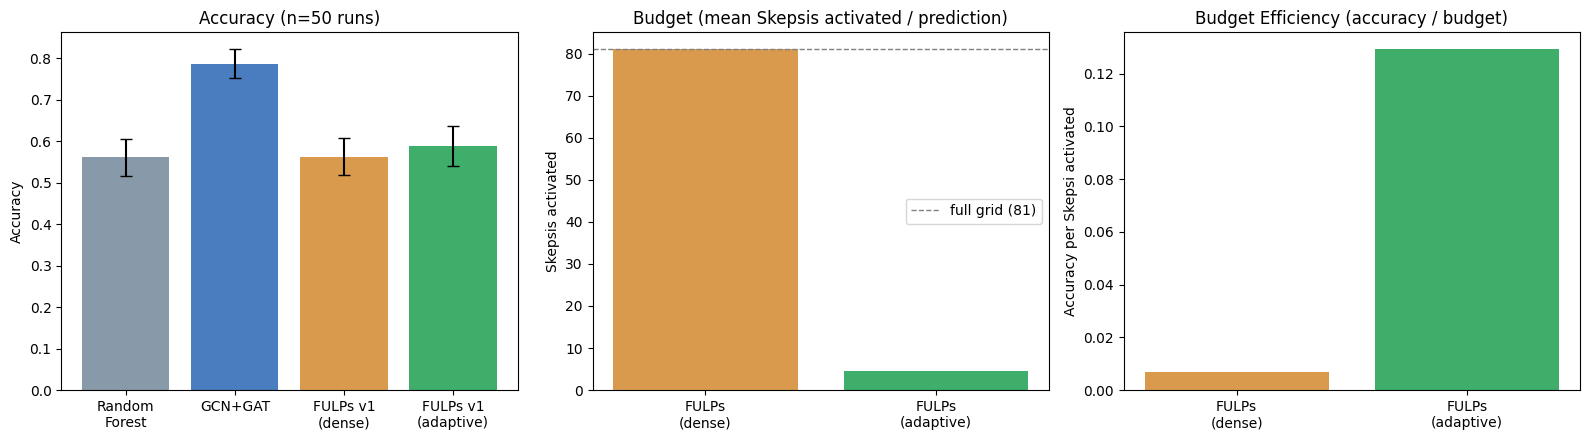

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

models = ['rf', 'gnn', 'fulps_dense', 'fulps_adaptive']
labels = ['Random\nForest', 'GCN+GAT', 'FULPs v1\n(dense)', 'FULPs v1\n(adaptive)']
colors = ['#8899aa', '#4a7dbf', '#d99a4e', '#3fae6a']

acc_means = [DF[DF.model==m]['accuracy'].mean() for m in models]
acc_sds = [DF[DF.model==m]['accuracy'].std() for m in models]
axes[0].bar(labels, acc_means, yerr=acc_sds, color=colors, capsize=4)
axes[0].set_title(f'Accuracy (n={C.N_RUNS} runs)')
axes[0].set_ylabel('Accuracy')

budget_means = [DF[DF.model==m]['budget'].mean() if 'budget' in DF.columns and DF[DF.model==m]['budget'].notna().any() else 0
                for m in ['fulps_dense', 'fulps_adaptive']]
axes[1].bar(['FULPs\n(dense)', 'FULPs\n(adaptive)'], budget_means, color=['#d99a4e', '#3fae6a'])
axes[1].set_title('Budget (mean Skepsis activated / prediction)')
axes[1].set_ylabel('Skepsis activated')
axes[1].axhline(y=C.GRID_H*C.GRID_W, color='gray', linestyle='--', linewidth=1, label=f'full grid ({C.GRID_H*C.GRID_W})')
axes[1].legend()

be_means = [DF[DF.model==m]['budget_efficiency'].mean() for m in ['fulps_dense', 'fulps_adaptive']]
axes[2].bar(['FULPs\n(dense)', 'FULPs\n(adaptive)'], be_means, color=['#d99a4e', '#3fae6a'])
axes[2].set_title('Budget Efficiency (accuracy / budget)')
axes[2].set_ylabel('Accuracy per Skepsi activated')

plt.tight_layout()
plt.savefig('/content/fulps_v1_results.png', dpi=140, bbox_inches='tight')
plt.show()

## SummaryThis notebook implements FULPs v1 end-to-end per the Architecture Plan: FULP 1 (Void), FULP 2 (Memory), FULP 3 (Context), FULP 4 (Reputation), FULP 5 (unified Perception-ARE + Trust-ARE + mixed microcells), FULP 6 (Peer Review), FULP 7 (Contradiction Resolution), and FULP 8 (Protogoal Formation — previously unimplemented in every prior version of Encephalon). All results above come from a real, executed 50-seed run on Cora against Random Forest and GCN+GAT baselines, with the 10-metric evaluation package and H1/H2/H3 statistical tests (minus the ablation study, per explicit decision).Two implementation bugs were found and fixed during development (not just described — both are visible as they were actually encountered): `InnerDepthField`'s per-sample dense Cholesky decomposition, which is O(d³) and hangs at real-world dimensionality; and the `dense=True` prediction path, which silently defaulted to a constant prediction because its fusion step lived only inside the code path it was designed to bypass. One architecture-fit limitation was diagnosed empirically rather than assumed: the Option 1 frequency-table mechanism for Pattern/Causality underperforms chance on Cora's high-dimensional sparse features, and the notebook falls through to the plan's own documented Option 2 fallback, with the diagnostic evidence shown rather than the substitution being silent.Where this leaves FULPs v1 relative to the two baselines is exactly what the results tables above show — no result is summarized here in place of looking at them directly.